In [45]:
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "IPython.extensions.autoreload" not in ip.extension_manager.loaded:
        ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "lif_utils.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import snntorch as snn
import matplotlib.pyplot as plt
import pandas as pd

from src import lif_utils as lu






In [46]:
SHAPE_TO_LABEL = {
    "seven": 0,
    "box": 1,
    "tee": 2,
    "ell": 3,
}

LABEL_TO_SHAPE = {
    label: shape_name
    for shape_name, label in SHAPE_TO_LABEL.items()
}

SHAPE_NAMES = list(SHAPE_TO_LABEL.keys())

SHAPE_TO_LABEL

{'seven': 0, 'box': 1, 'tee': 2, 'ell': 3}

In [47]:
GOOD_VELOCITY_PARAMS = {
    "threshold_velocity": 15.0,
    "input_scale": 1.0,
    "beta_velocity": 0.8,
    "inhibition_strength": 3.0,
    "inhibition_radius": 1,
    "internal_steps": 5,
}

lu.GOOD_VELOCITY_PARAMS = GOOD_VELOCITY_PARAMS


In [ ]:
CANVAS_HEIGHT = 64
CANVAS_WIDTH = 64
STEPS = 7

INTENSITY = 1.0

SHAPE_TEMPLATES = lu.make_toy_2d_shape_templates()

DIRECTION_CONFIG = {
    "right": {"velocity_y": 0, "velocity_x": 1, "start_top": 28, "start_left": 10},
    "left":  {"velocity_y": 0, "velocity_x": -1, "start_top": 28, "start_left": 45},
    "down":  {"velocity_y": 1, "velocity_x": 0, "start_top": 10, "start_left": 28},
    "up":    {"velocity_y": -1, "velocity_x": 0, "start_top": 45, "start_left": 28},
}

lu.CANVAS_HEIGHT = CANVAS_HEIGHT
lu.CANVAS_WIDTH = CANVAS_WIDTH
lu.STEPS = STEPS
lu.INTENSITY = INTENSITY
lu.SHAPE_TEMPLATES = SHAPE_TEMPLATES
lu.DIRECTION_CONFIG = DIRECTION_CONFIG


In [49]:
def sample_random_velocity_sequence(
    num_transitions,
    max_speed=6,
    allow_stationary=False,
    seed=None,
):
    """
    Sample a random velocity sequence.

    Each velocity is an integer pair (dy, dx), bounded by max_speed.
    We avoid (0,0) unless allow_stationary=True.
    """

    if seed is not None:
        torch.manual_seed(seed)

    velocity_sequence = []

    for _ in range(num_transitions):
        while True:
            dy = int(torch.randint(-max_speed, max_speed + 1, (1,)).item())
            dx = int(torch.randint(-max_speed, max_speed + 1, (1,)).item())

            if allow_stationary or dy != 0 or dx != 0:
                break

        velocity_sequence.append((dy, dx))

    return velocity_sequence

In [50]:
def choose_safe_start_position_for_velocity_sequence(
    shape_name,
    velocity_sequence,
    canvas_height=CANVAS_HEIGHT,
    canvas_width=CANVAS_WIDTH,
    margin=8,
    seed=None,
):
    """
    Choose a start position so the object is likely to stay inside the canvas.
    """

    if seed is not None:
        torch.manual_seed(seed)

    shape = SHAPE_TEMPLATES[shape_name]
    shape_height, shape_width = shape.shape

    cumulative_y = [0]
    cumulative_x = [0]

    current_y = 0
    current_x = 0

    for dy, dx in velocity_sequence:
        current_y += dy
        current_x += dx
        cumulative_y.append(current_y)
        cumulative_x.append(current_x)

    min_cum_y = min(cumulative_y)
    max_cum_y = max(cumulative_y)
    min_cum_x = min(cumulative_x)
    max_cum_x = max(cumulative_x)

    min_start_y = margin - min_cum_y
    max_start_y = canvas_height - shape_height - margin - max_cum_y

    min_start_x = margin - min_cum_x
    max_start_x = canvas_width - shape_width - margin - max_cum_x

    if min_start_y > max_start_y or min_start_x > max_start_x:
        raise ValueError("Velocity sequence too large to fit safely on canvas.")

    start_top = int(torch.randint(min_start_y, max_start_y + 1, (1,)).item())
    start_left = int(torch.randint(min_start_x, max_start_x + 1, (1,)).item())

    return start_top, start_left

In [57]:
def make_one_classifier_dataset_sample(
    shape_name,
    max_speed=3,
    sample_seed=0,
    max_velocity=3,
    max_displacement=18,
    velocity_params=None,
):
    """
    Generate one sample for classifier training.

    Returns:
        raw_spikes: [T, H, W]
        object_memory_spikes: [T, H, W]
        label: int
        metadata: dict
    """

    if velocity_params is None:
        velocity_params = GOOD_VELOCITY_PARAMS

    velocity_sequence = sample_random_velocity_sequence(
        num_transitions=STEPS - 1,
        max_speed=max_speed,
        allow_stationary=False,
        seed=sample_seed,
    )

    start_top, start_left = choose_safe_start_position_for_velocity_sequence(
        shape_name=shape_name,
        velocity_sequence=velocity_sequence,
        seed=sample_seed + 10000,
    )

    case = lu.make_variable_velocity_spike_case(
        velocity_sequence=velocity_sequence,
        shape_name=shape_name,
        start_top=start_top,
        start_left=start_left,
    )

    object_memory_result = lu.run_displacement_gated_object_memory(
        case=case,
        max_velocity=max_velocity,
        max_displacement=max_displacement,
        velocity_params=velocity_params,
        threshold_memory=1.5,
        beta_memory=0.8,
        reset_mode="subtract",
    )

    raw_spikes = case["spikes"].float()
    object_memory_spikes = object_memory_result["memory_spike_history"].float()

    label = SHAPE_TO_LABEL[shape_name]

    metadata = {
        "shape_name": shape_name,
        "label": label,
        "velocity_sequence": velocity_sequence,
        "start_top": start_top,
        "start_left": start_left,
        "origins": case["origins"],
        "raw_total_spikes": int(raw_spikes.sum().item()),
        "object_memory_total_spikes": int(object_memory_spikes.sum().item()),
    }

    return {
        "raw_spikes": raw_spikes,
        "object_memory_spikes": object_memory_spikes,
        "label": label,
        "metadata": metadata,
    }

In [52]:
def build_classifier_dataset(
    samples_per_shape=25,
    max_speed=3,
    max_velocity=3,
    max_displacement=18,
    base_seed=0,
):
    """
    Build a dataset of raw moving spikes and stabilized ObjectMemory spikes.

    Output tensors:
        raw_spikes_dataset: [N, T, H, W]
        object_memory_spikes_dataset: [N, T, H, W]
        labels: [N]
    """

    raw_samples = []
    object_memory_samples = []
    labels = []
    metadata_rows = []

    sample_index = 0

    for shape_name in SHAPE_NAMES:
        for k in range(samples_per_shape):
            sample_seed = base_seed + sample_index

            print(f"Generating sample {sample_index}: shape={shape_name}, seed={sample_seed}")

            sample = make_one_classifier_dataset_sample(
                shape_name=shape_name,
                max_speed=max_speed,
                sample_seed=sample_seed,
                max_velocity=max_velocity,
                max_displacement=max_displacement,
            )

            raw_samples.append(sample["raw_spikes"])
            object_memory_samples.append(sample["object_memory_spikes"])
            labels.append(sample["label"])

            metadata = sample["metadata"]
            metadata["sample_index"] = sample_index
            metadata_rows.append(metadata)

            sample_index += 1

    raw_spikes_dataset = torch.stack(raw_samples, dim=0)
    object_memory_spikes_dataset = torch.stack(object_memory_samples, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)
    metadata_table = pd.DataFrame(metadata_rows)

    return {
        "raw_spikes_dataset": raw_spikes_dataset,
        "object_memory_spikes_dataset": object_memory_spikes_dataset,
        "labels": labels,
        "metadata_table": metadata_table,
    }

In [53]:
classifier_dataset = build_classifier_dataset(
    samples_per_shape=10,
    max_speed=3,
    max_velocity=3,
    max_displacement=18,
    base_seed=0,
)

Generating sample 0: shape=seven, seed=0
Generating sample 1: shape=seven, seed=1
Generating sample 2: shape=seven, seed=2
Generating sample 3: shape=seven, seed=3
Generating sample 4: shape=seven, seed=4
Generating sample 5: shape=seven, seed=5
Generating sample 6: shape=seven, seed=6
Generating sample 7: shape=seven, seed=7
Generating sample 8: shape=seven, seed=8
Generating sample 9: shape=seven, seed=9
Generating sample 10: shape=box, seed=10
Generating sample 11: shape=box, seed=11
Generating sample 12: shape=box, seed=12
Generating sample 13: shape=box, seed=13
Generating sample 14: shape=box, seed=14
Generating sample 15: shape=box, seed=15
Generating sample 16: shape=box, seed=16
Generating sample 17: shape=box, seed=17
Generating sample 18: shape=box, seed=18
Generating sample 19: shape=box, seed=19
Generating sample 20: shape=tee, seed=20
Generating sample 21: shape=tee, seed=21
Generating sample 22: shape=tee, seed=22
Generating sample 23: shape=tee, seed=23
Generating sampl

In [54]:
raw_spikes_dataset = classifier_dataset["raw_spikes_dataset"]
object_memory_spikes_dataset = classifier_dataset["object_memory_spikes_dataset"]
labels = classifier_dataset["labels"]
metadata_table = classifier_dataset["metadata_table"]

print("raw_spikes_dataset:", raw_spikes_dataset.shape)
print("object_memory_spikes_dataset:", object_memory_spikes_dataset.shape)
print("labels:", labels.shape)

metadata_table.head()

raw_spikes_dataset: torch.Size([40, 7, 64, 64])
object_memory_spikes_dataset: torch.Size([40, 7, 64, 64])
labels: torch.Size([40])


,shape_name,label,velocity_sequence,start_top,start_left,origins,raw_total_spikes,object_memory_total_spikes,sample_index
0,seven,0,"[(1, 0), (-3, -1), (-2, -1), (3, 0), (1, 2), (...",23,37,"[(23, 37), (24, 37), (21, 36), (19, 35), (22, ...",63,63,0
1,seven,0,"[(-3, 0), (1, 0), (0, 3), (-3, 2), (-3, 0), (1...",41,27,"[(41, 27), (38, 27), (39, 27), (39, 30), (36, ...",63,63,1
2,seven,0,"[(-1, 0), (1, -1), (1, -3), (3, 2), (1, 1), (-...",14,17,"[(14, 17), (13, 17), (14, 16), (15, 13), (18, ...",63,63,2
3,seven,0,"[(2, 0), (0, 1), (-3, 3), (-1, 1), (2, -3), (3...",26,46,"[(26, 46), (28, 46), (28, 47), (25, 50), (24, ...",63,63,3
4,seven,0,"[(0, 3), (2, 0), (-2, -3), (-1, 1), (2, -3), (...",47,10,"[(47, 10), (47, 13), (49, 13), (47, 10), (46, ...",63,63,4


In [55]:
metadata_table["shape_name"].value_counts()

shape_name
seven    10
box      10
tee      10
ell      10
Name: count, dtype: int64

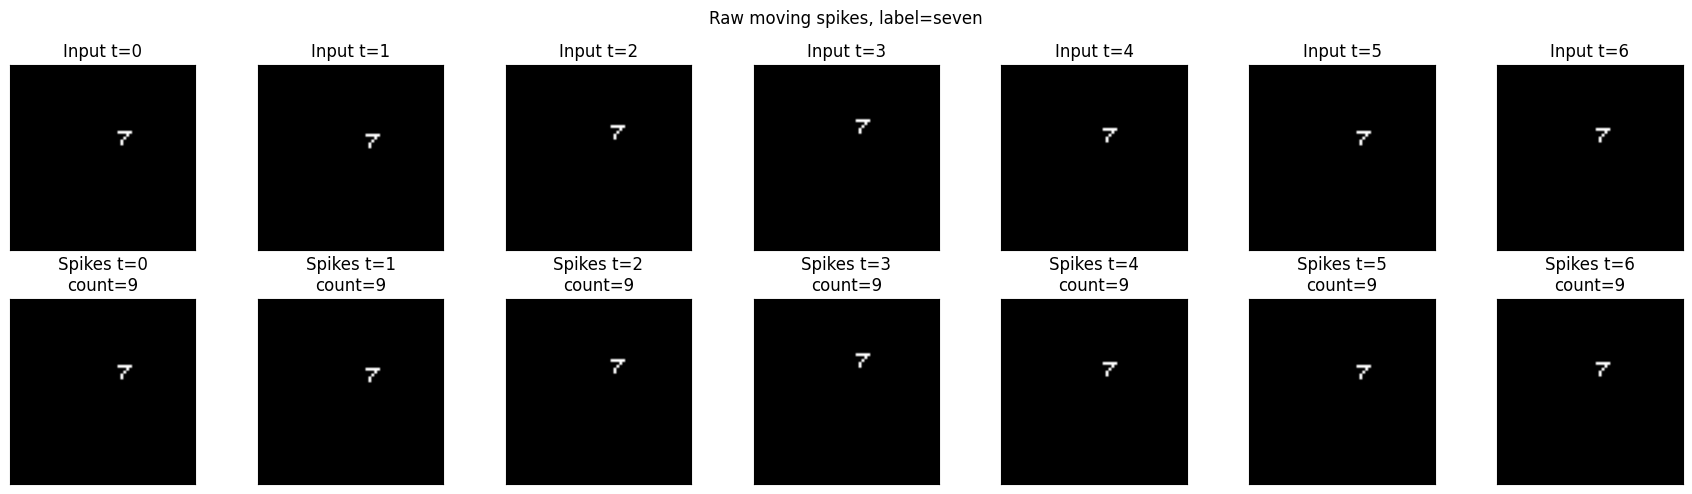

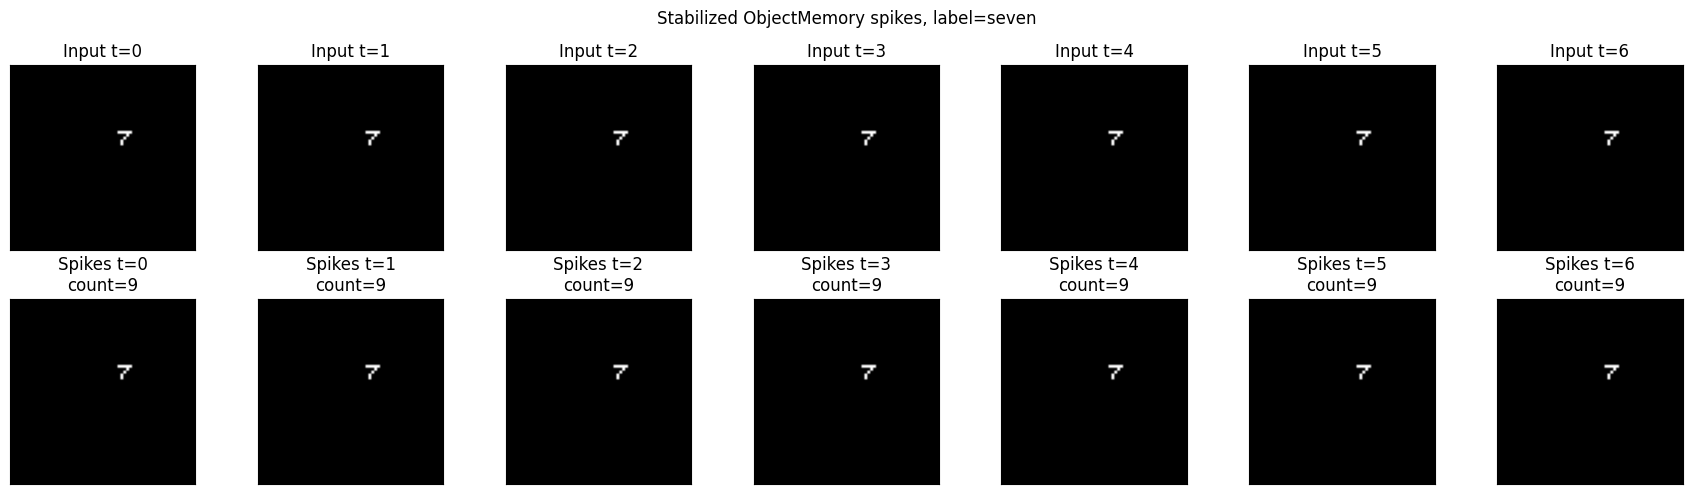

In [56]:
sample_index = 0

sample_case_like_raw = {
    "spikes": raw_spikes_dataset[sample_index],
    "frames": raw_spikes_dataset[sample_index],
    "shape_name": LABEL_TO_SHAPE[int(labels[sample_index].item())],
}

sample_case_like_memory = {
    "spikes": object_memory_spikes_dataset[sample_index],
    "frames": object_memory_spikes_dataset[sample_index],
    "shape_name": LABEL_TO_SHAPE[int(labels[sample_index].item())],
}

lu.plot_input_next_to_spikes_general(
    sample_case_like_raw,
    title=f"Raw moving spikes, label={LABEL_TO_SHAPE[int(labels[sample_index].item())]}"
)

lu.plot_input_next_to_spikes_general(
    sample_case_like_memory,
    title=f"Stabilized ObjectMemory spikes, label={LABEL_TO_SHAPE[int(labels[sample_index].item())]}"
)

In [58]:
classifier_dataset = build_classifier_dataset(
    samples_per_shape=100,
    max_speed=3,
    max_velocity=3,
    max_displacement=18,
    base_seed=0,
)

Generating sample 0: shape=seven, seed=0
Generating sample 1: shape=seven, seed=1
Generating sample 2: shape=seven, seed=2
Generating sample 3: shape=seven, seed=3
Generating sample 4: shape=seven, seed=4
Generating sample 5: shape=seven, seed=5
Generating sample 6: shape=seven, seed=6
Generating sample 7: shape=seven, seed=7
Generating sample 8: shape=seven, seed=8
Generating sample 9: shape=seven, seed=9
Generating sample 10: shape=seven, seed=10
Generating sample 11: shape=seven, seed=11
Generating sample 12: shape=seven, seed=12
Generating sample 13: shape=seven, seed=13
Generating sample 14: shape=seven, seed=14
Generating sample 15: shape=seven, seed=15
Generating sample 16: shape=seven, seed=16
Generating sample 17: shape=seven, seed=17
Generating sample 18: shape=seven, seed=18
Generating sample 19: shape=seven, seed=19
Generating sample 20: shape=seven, seed=20
Generating sample 21: shape=seven, seed=21
Generating sample 22: shape=seven, seed=22
Generating sample 23: shape=sev

In [59]:
raw_spikes_dataset = classifier_dataset["raw_spikes_dataset"]
object_memory_spikes_dataset = classifier_dataset["object_memory_spikes_dataset"]
labels = classifier_dataset["labels"]
metadata_table = classifier_dataset["metadata_table"]

print("raw_spikes_dataset:", raw_spikes_dataset.shape)
print("object_memory_spikes_dataset:", object_memory_spikes_dataset.shape)
print("labels:", labels.shape)

metadata_table["shape_name"].value_counts()

raw_spikes_dataset: torch.Size([400, 7, 64, 64])
object_memory_spikes_dataset: torch.Size([400, 7, 64, 64])
labels: torch.Size([400])


shape_name
seven    100
box      100
tee      100
ell      100
Name: count, dtype: int64

In [66]:
num_classes = len(SHAPE_TO_LABEL)
num_steps = raw_spikes_dataset.shape[1]
height = raw_spikes_dataset.shape[2]
width = raw_spikes_dataset.shape[3]

print(num_classes, num_steps, height, width)

4 7 64 64


In [63]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import snntorch as snn
from snntorch import surrogate

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [64]:
def make_train_test_split(num_samples, train_fraction=0.8, seed=0):
    torch.manual_seed(seed)

    indices = torch.randperm(num_samples)
    train_size = int(train_fraction * num_samples)

    train_indices = indices[:train_size]
    test_indices = indices[train_size:]

    return train_indices, test_indices


train_indices, test_indices = make_train_test_split(
    num_samples=labels.shape[0],
    train_fraction=0.8,
    seed=0,
)

print("train:", train_indices.shape)
print("test:", test_indices.shape)

train: torch.Size([320])
test: torch.Size([80])


In [67]:
def make_dataloaders(spike_dataset, labels, train_indices, test_indices, batch_size=32):
    """
    spike_dataset shape: [N, T, H, W]
    labels shape: [N]
    """

    train_spikes = spike_dataset[train_indices].float()
    train_labels = labels[train_indices].long()

    test_spikes = spike_dataset[test_indices].float()
    test_labels = labels[test_indices].long()

    train_dataset = TensorDataset(train_spikes, train_labels)
    test_dataset = TensorDataset(test_spikes, test_labels)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, test_loader

In [68]:
raw_train_loader, raw_test_loader = make_dataloaders(
    raw_spikes_dataset,
    labels,
    train_indices,
    test_indices,
    batch_size=32,
)

memory_train_loader, memory_test_loader = make_dataloaders(
    object_memory_spikes_dataset,
    labels,
    train_indices,
    test_indices,
    batch_size=32,
)

In [69]:
class SmallSpikingCNN(nn.Module):
    def __init__(
        self,
        num_classes=4,
        beta=0.9,
        height=64,
        width=64,
    ):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=5,
            stride=2,
            padding=2,
        )
        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad,
        )

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=5,
            stride=2,
            padding=2,
        )
        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad,
        )

        # For 64x64:
        # after conv1 stride 2: 32x32
        # after conv2 stride 2: 16x16
        conv_output_height = height // 4
        conv_output_width = width // 4
        flattened_size = 16 * conv_output_height * conv_output_width

        self.fc1 = nn.Linear(flattened_size, 64)
        self.lif3 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad,
        )

        self.fc_out = nn.Linear(64, num_classes)

    def forward(self, spike_movie):
        """
        spike_movie shape: [batch, T, H, W]

        Returns:
            class_scores shape: [batch, num_classes]
        """

        batch_size, num_steps, height, width = spike_movie.shape

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        class_scores = torch.zeros(
            batch_size,
            self.fc_out.out_features,
            device=spike_movie.device,
        )

        for t in range(num_steps):
            x_t = spike_movie[:, t].unsqueeze(1)  # [batch, 1, H, W]

            cur1 = self.conv1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            flat = spk2.flatten(start_dim=1)

            cur3 = self.fc1(flat)
            spk3, mem3 = self.lif3(cur3, mem3)

            # Non-spiking class readout.
            # We accumulate evidence across time.
            class_scores = class_scores + self.fc_out(spk3)

        return class_scores

In [70]:
def compute_accuracy(model, data_loader, device):
    model.eval()

    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for spike_movies, batch_labels in data_loader:
            spike_movies = spike_movies.to(device)
            batch_labels = batch_labels.to(device)

            class_scores = model(spike_movies)
            predictions = class_scores.argmax(dim=1)

            total_correct += (predictions == batch_labels).sum().item()
            total_examples += batch_labels.shape[0]

    return total_correct / total_examples


def train_snn_classifier(
    train_loader,
    test_loader,
    num_classes=4,
    height=64,
    width=64,
    num_epochs=20,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
):
    model = SmallSpikingCNN(
        num_classes=num_classes,
        beta=beta,
        height=height,
        width=width,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    loss_fn = nn.CrossEntropyLoss()

    history = []

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_examples = 0

        for spike_movies, batch_labels in train_loader:
            spike_movies = spike_movies.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()

            class_scores = model(spike_movies)
            loss = loss_fn(class_scores, batch_labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_labels.shape[0]
            total_examples += batch_labels.shape[0]

        train_loss = total_loss / total_examples
        train_accuracy = compute_accuracy(model, train_loader, device)
        test_accuracy = compute_accuracy(model, test_loader, device)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        }
        history.append(row)

        print(
            f"epoch {epoch:02d} | "
            f"loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.3f} | "
            f"test acc {test_accuracy:.3f}"
        )

    history = pd.DataFrame(history)

    return model, history

In [71]:
num_classes = len(SHAPE_TO_LABEL)
height = raw_spikes_dataset.shape[2]
width = raw_spikes_dataset.shape[3]

raw_model, raw_history = train_snn_classifier(
    train_loader=raw_train_loader,
    test_loader=raw_test_loader,
    num_classes=num_classes,
    height=height,
    width=width,
    num_epochs=20,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
)

epoch 00 | loss 1.5755 | train acc 0.250 | test acc 0.250
epoch 01 | loss 1.5421 | train acc 0.250 | test acc 0.250
epoch 02 | loss 1.5132 | train acc 0.250 | test acc 0.250
epoch 03 | loss 1.4795 | train acc 0.250 | test acc 0.250
epoch 04 | loss 1.5537 | train acc 0.375 | test acc 0.362
epoch 05 | loss 1.3228 | train acc 0.419 | test acc 0.338
epoch 06 | loss 1.2306 | train acc 0.484 | test acc 0.338
epoch 07 | loss 1.1775 | train acc 0.487 | test acc 0.350
epoch 08 | loss 1.1051 | train acc 0.522 | test acc 0.312
epoch 09 | loss 1.0497 | train acc 0.609 | test acc 0.375
epoch 10 | loss 0.9913 | train acc 0.650 | test acc 0.375
epoch 11 | loss 0.9558 | train acc 0.675 | test acc 0.412
epoch 12 | loss 0.9059 | train acc 0.662 | test acc 0.412
epoch 13 | loss 0.8371 | train acc 0.719 | test acc 0.438
epoch 14 | loss 0.7802 | train acc 0.750 | test acc 0.463
epoch 15 | loss 0.7290 | train acc 0.800 | test acc 0.438
epoch 16 | loss 0.6580 | train acc 0.787 | test acc 0.463
epoch 17 | los

In [72]:
memory_model, memory_history = train_snn_classifier(
    train_loader=memory_train_loader,
    test_loader=memory_test_loader,
    num_classes=num_classes,
    height=height,
    width=width,
    num_epochs=20,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
)

epoch 00 | loss 1.4697 | train acc 0.269 | test acc 0.175
epoch 01 | loss 1.4543 | train acc 0.269 | test acc 0.175
epoch 02 | loss 1.4415 | train acc 0.269 | test acc 0.175
epoch 03 | loss 1.4310 | train acc 0.269 | test acc 0.175
epoch 04 | loss 1.4211 | train acc 0.269 | test acc 0.175
epoch 05 | loss 1.4202 | train acc 0.250 | test acc 0.250
epoch 06 | loss 1.3730 | train acc 0.338 | test acc 0.188
epoch 07 | loss 1.3460 | train acc 0.466 | test acc 0.263
epoch 08 | loss 1.2447 | train acc 0.500 | test acc 0.275
epoch 09 | loss 1.1451 | train acc 0.522 | test acc 0.287
epoch 10 | loss 1.0173 | train acc 0.644 | test acc 0.350
epoch 11 | loss 0.8925 | train acc 0.706 | test acc 0.362
epoch 12 | loss 0.9085 | train acc 0.728 | test acc 0.312
epoch 13 | loss 0.7900 | train acc 0.744 | test acc 0.275
epoch 14 | loss 0.6985 | train acc 0.803 | test acc 0.300
epoch 15 | loss 0.5578 | train acc 0.875 | test acc 0.375
epoch 16 | loss 0.4499 | train acc 0.878 | test acc 0.350
epoch 17 | los

In [73]:
comparison_table = pd.DataFrame({
    "epoch": raw_history["epoch"],
    "raw_train_accuracy": raw_history["train_accuracy"],
    "raw_test_accuracy": raw_history["test_accuracy"],
    "memory_train_accuracy": memory_history["train_accuracy"],
    "memory_test_accuracy": memory_history["test_accuracy"],
})

comparison_table

,epoch,raw_train_accuracy,raw_test_accuracy,memory_train_accuracy,memory_test_accuracy
0,0,0.250000,0.2500,0.268750,0.1750
1,1,0.250000,0.2500,0.268750,0.1750
2,2,0.250000,0.2500,0.268750,0.1750
3,3,0.250000,0.2500,0.268750,0.1750
4,4,0.375000,0.3625,0.268750,0.1750
5,5,0.418750,0.3375,0.250000,0.2500
6,6,0.484375,0.3375,0.337500,0.1875
7,7,0.487500,0.3500,0.465625,0.2625
8,8,0.521875,0.3125,0.500000,0.2750
9,9,0.609375,0.3750,0.521875,0.2875


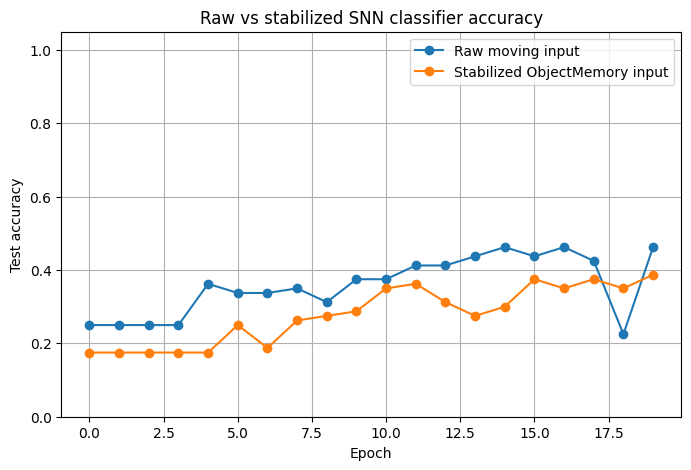

In [74]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_table["epoch"],
    comparison_table["raw_test_accuracy"],
    marker="o",
    label="Raw moving input",
)

plt.plot(
    comparison_table["epoch"],
    comparison_table["memory_test_accuracy"],
    marker="o",
    label="Stabilized ObjectMemory input",
)

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Raw vs stabilized SNN classifier accuracy")
plt.ylim(0.0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

In [75]:
def inspect_model_activity(model, data_loader, device, num_batches=1):
    model.eval()

    with torch.no_grad():
        for batch_index, (spike_movies, batch_labels) in enumerate(data_loader):
            if batch_index >= num_batches:
                break

            spike_movies = spike_movies.to(device)
            batch_labels = batch_labels.to(device)

            batch_size, num_steps, height, width = spike_movies.shape

            mem1 = model.lif1.init_leaky()
            mem2 = model.lif2.init_leaky()
            mem3 = model.lif3.init_leaky()

            total_input_spikes = spike_movies.sum().item()
            total_spk1 = 0.0
            total_spk2 = 0.0
            total_spk3 = 0.0

            for t in range(num_steps):
                x_t = spike_movies[:, t].unsqueeze(1)

                cur1 = model.conv1(x_t)
                spk1, mem1 = model.lif1(cur1, mem1)

                cur2 = model.conv2(spk1)
                spk2, mem2 = model.lif2(cur2, mem2)

                flat = spk2.flatten(start_dim=1)

                cur3 = model.fc1(flat)
                spk3, mem3 = model.lif3(cur3, mem3)

                total_spk1 += spk1.sum().item()
                total_spk2 += spk2.sum().item()
                total_spk3 += spk3.sum().item()

            print("input spikes:", total_input_spikes)
            print("layer 1 spikes:", total_spk1)
            print("layer 2 spikes:", total_spk2)
            print("layer 3 spikes:", total_spk3)

In [76]:
class SmallSpikingCNNV2(nn.Module):
    def __init__(
        self,
        num_classes=4,
        beta=0.9,
        height=64,
        width=64,
    ):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid(slope=25)

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=5,
            stride=1,
            padding=2,
        )
        self.lif1 = snn.Leaky(
            beta=beta,
            threshold=0.5,
            spike_grad=spike_grad,
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=5,
            stride=2,
            padding=2,
        )
        self.lif2 = snn.Leaky(
            beta=beta,
            threshold=0.5,
            spike_grad=spike_grad,
        )

        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=32,
            kernel_size=5,
            stride=2,
            padding=2,
        )
        self.lif3 = snn.Leaky(
            beta=beta,
            threshold=0.5,
            spike_grad=spike_grad,
        )

        conv_output_height = height // 4
        conv_output_width = width // 4
        flattened_size = 32 * conv_output_height * conv_output_width

        self.fc1 = nn.Linear(flattened_size, 128)
        self.lif4 = snn.Leaky(
            beta=beta,
            threshold=0.5,
            spike_grad=spike_grad,
        )

        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, spike_movie):
        """
        spike_movie shape: [batch, T, H, W]
        """

        batch_size, num_steps, height, width = spike_movie.shape

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()

        class_scores = torch.zeros(
            batch_size,
            self.fc_out.out_features,
            device=spike_movie.device,
        )

        for t in range(num_steps):
            x_t = spike_movie[:, t].unsqueeze(1)

            cur1 = self.conv1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.conv3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)

            flat = spk3.flatten(start_dim=1)

            cur4 = self.fc1(flat)
            spk4, mem4 = self.lif4(cur4, mem4)

            # Important change:
            # use membrane evidence, not just spikes.
            class_scores = class_scores + self.fc_out(mem4)

        return class_scores

In [77]:
def train_snn_classifier_v2(
    train_loader,
    test_loader,
    num_classes=4,
    height=64,
    width=64,
    num_epochs=50,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
):
    model = SmallSpikingCNNV2(
        num_classes=num_classes,
        beta=beta,
        height=height,
        width=width,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-5,
    )

    loss_fn = nn.CrossEntropyLoss()

    history = []

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_examples = 0

        for spike_movies, batch_labels in train_loader:
            spike_movies = spike_movies.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()

            class_scores = model(spike_movies)
            loss = loss_fn(class_scores, batch_labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_labels.shape[0]
            total_examples += batch_labels.shape[0]

        train_loss = total_loss / total_examples
        train_accuracy = compute_accuracy(model, train_loader, device)
        test_accuracy = compute_accuracy(model, test_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        })

        print(
            f"epoch {epoch:02d} | "
            f"loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.3f} | "
            f"test acc {test_accuracy:.3f}"
        )

    return model, pd.DataFrame(history)

In [78]:
raw_model_v2, raw_history_v2 = train_snn_classifier_v2(
    train_loader=raw_train_loader,
    test_loader=raw_test_loader,
    num_classes=num_classes,
    height=height,
    width=width,
    num_epochs=50,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
)

epoch 00 | loss 1.4440 | train acc 0.600 | test acc 0.325
epoch 01 | loss 1.1412 | train acc 0.672 | test acc 0.400
epoch 02 | loss 0.8739 | train acc 0.750 | test acc 0.375
epoch 03 | loss 0.7555 | train acc 0.787 | test acc 0.463
epoch 04 | loss 0.5352 | train acc 0.863 | test acc 0.475
epoch 05 | loss 0.3932 | train acc 0.906 | test acc 0.425
epoch 06 | loss 0.2948 | train acc 0.975 | test acc 0.438
epoch 07 | loss 0.1999 | train acc 0.975 | test acc 0.400
epoch 08 | loss 0.1347 | train acc 0.994 | test acc 0.450
epoch 09 | loss 0.0983 | train acc 0.994 | test acc 0.463
epoch 10 | loss 0.0742 | train acc 1.000 | test acc 0.487
epoch 11 | loss 0.0360 | train acc 1.000 | test acc 0.463
epoch 12 | loss 0.0201 | train acc 1.000 | test acc 0.425
epoch 13 | loss 0.0181 | train acc 1.000 | test acc 0.450
epoch 14 | loss 0.0159 | train acc 1.000 | test acc 0.438
epoch 15 | loss 0.0372 | train acc 0.988 | test acc 0.463
epoch 16 | loss 0.0725 | train acc 0.988 | test acc 0.537
epoch 17 | los

In [79]:
memory_model_v2, memory_history_v2 = train_snn_classifier_v2(
    train_loader=memory_train_loader,
    test_loader=memory_test_loader,
    num_classes=num_classes,
    height=height,
    width=width,
    num_epochs=50,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
)

epoch 00 | loss 1.4245 | train acc 0.669 | test acc 0.300
epoch 01 | loss 1.0203 | train acc 0.875 | test acc 0.312
epoch 02 | loss 0.5843 | train acc 0.959 | test acc 0.312
epoch 03 | loss 0.2636 | train acc 0.963 | test acc 0.325
epoch 04 | loss 0.0773 | train acc 0.997 | test acc 0.325
epoch 05 | loss 0.0203 | train acc 1.000 | test acc 0.362
epoch 06 | loss 0.0067 | train acc 1.000 | test acc 0.350
epoch 07 | loss 0.0022 | train acc 1.000 | test acc 0.338
epoch 08 | loss 0.0010 | train acc 1.000 | test acc 0.350
epoch 09 | loss 0.0007 | train acc 1.000 | test acc 0.350
epoch 10 | loss 0.0004 | train acc 1.000 | test acc 0.362
epoch 11 | loss 0.0003 | train acc 1.000 | test acc 0.375
epoch 12 | loss 0.0003 | train acc 1.000 | test acc 0.362
epoch 13 | loss 0.0002 | train acc 1.000 | test acc 0.362
epoch 14 | loss 0.0002 | train acc 1.000 | test acc 0.362
epoch 15 | loss 0.0002 | train acc 1.000 | test acc 0.362
epoch 16 | loss 0.0001 | train acc 1.000 | test acc 0.338
epoch 17 | los

In [80]:
def make_tiny_loader(spike_dataset, labels, num_examples=32, batch_size=32):
    tiny_spikes = spike_dataset[:num_examples].float()
    tiny_labels = labels[:num_examples].long()

    tiny_dataset = TensorDataset(tiny_spikes, tiny_labels)

    tiny_loader = DataLoader(
        tiny_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    return tiny_loader

In [81]:
tiny_memory_loader = make_tiny_loader(
    object_memory_spikes_dataset,
    labels,
    num_examples=32,
    batch_size=32,
)

tiny_model, tiny_history = train_snn_classifier_v2(
    train_loader=tiny_memory_loader,
    test_loader=tiny_memory_loader,
    num_classes=num_classes,
    height=height,
    width=width,
    num_epochs=100,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
)

epoch 00 | loss 1.4335 | train acc 1.000 | test acc 1.000
epoch 01 | loss 1.1311 | train acc 1.000 | test acc 1.000
epoch 02 | loss 0.0879 | train acc 1.000 | test acc 1.000
epoch 03 | loss 0.0025 | train acc 1.000 | test acc 1.000
epoch 04 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 05 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 06 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 07 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 08 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 09 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 10 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 11 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 12 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 13 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 14 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 15 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 16 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 17 | los

In [82]:
def make_balanced_tiny_loader(
    spike_dataset,
    labels,
    examples_per_class=8,
    batch_size=32,
    seed=0,
):
    torch.manual_seed(seed)

    selected_indices = []

    unique_labels = torch.unique(labels)

    for class_label in unique_labels:
        class_indices = torch.nonzero(labels == class_label, as_tuple=False).squeeze(1)
        shuffled = class_indices[torch.randperm(class_indices.shape[0])]
        selected_indices.append(shuffled[:examples_per_class])

    selected_indices = torch.cat(selected_indices)
    selected_indices = selected_indices[torch.randperm(selected_indices.shape[0])]

    tiny_spikes = spike_dataset[selected_indices].float()
    tiny_labels = labels[selected_indices].long()

    tiny_dataset = TensorDataset(tiny_spikes, tiny_labels)

    tiny_loader = DataLoader(
        tiny_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    return tiny_loader, selected_indices

In [83]:
balanced_tiny_memory_loader, balanced_tiny_indices = make_balanced_tiny_loader(
    object_memory_spikes_dataset,
    labels,
    examples_per_class=8,
    batch_size=32,
    seed=0,
)

print(labels[balanced_tiny_indices])

tensor([1, 3, 0, 1, 1, 1, 2, 3, 2, 2, 0, 3, 0, 2, 0, 2, 0, 2, 1, 3, 2, 3, 3, 0,
        0, 1, 1, 1, 2, 3, 3, 0])


In [84]:
balanced_tiny_model, balanced_tiny_history = train_snn_classifier_v2(
    train_loader=balanced_tiny_memory_loader,
    test_loader=balanced_tiny_memory_loader,
    num_classes=num_classes,
    height=height,
    width=width,
    num_epochs=100,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
)

epoch 00 | loss 1.4206 | train acc 0.531 | test acc 0.531
epoch 01 | loss 1.2546 | train acc 0.969 | test acc 0.969
epoch 02 | loss 0.9591 | train acc 0.938 | test acc 0.938
epoch 03 | loss 0.5371 | train acc 0.938 | test acc 0.938
epoch 04 | loss 0.2451 | train acc 0.969 | test acc 0.969
epoch 05 | loss 0.0634 | train acc 1.000 | test acc 1.000
epoch 06 | loss 0.0370 | train acc 1.000 | test acc 1.000
epoch 07 | loss 0.0145 | train acc 1.000 | test acc 1.000
epoch 08 | loss 0.0080 | train acc 1.000 | test acc 1.000
epoch 09 | loss 0.0151 | train acc 1.000 | test acc 1.000
epoch 10 | loss 0.0003 | train acc 1.000 | test acc 1.000
epoch 11 | loss 0.0033 | train acc 1.000 | test acc 1.000
epoch 12 | loss 0.0074 | train acc 1.000 | test acc 1.000
epoch 13 | loss 0.0001 | train acc 1.000 | test acc 1.000
epoch 14 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 15 | loss 0.0000 | train acc 1.000 | test acc 1.000
epoch 16 | loss 0.0001 | train acc 1.000 | test acc 1.000
epoch 17 | los

In [85]:
def get_predictions(model, data_loader, device):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for spike_movies, batch_labels in data_loader:
            spike_movies = spike_movies.to(device)

            class_scores = model(spike_movies)
            predictions = class_scores.argmax(dim=1).cpu()

            all_predictions.append(predictions)
            all_labels.append(batch_labels.cpu())

    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    return all_predictions, all_labels


def make_confusion_matrix(predictions, true_labels, num_classes):
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.long)

    for true_label, predicted_label in zip(true_labels, predictions):
        confusion[true_label, predicted_label] += 1

    return confusion

In [86]:
memory_predictions, memory_true_labels = get_predictions(
    memory_model_v2,
    memory_test_loader,
    device,
)

memory_confusion = make_confusion_matrix(
    memory_predictions,
    memory_true_labels,
    num_classes=num_classes,
)

memory_confusion

tensor([[11,  0,  5,  8],
        [ 2, 10,  6,  4],
        [ 4,  3,  5,  2],
        [ 3,  1, 10,  6]])

In [87]:
raw_predictions, raw_true_labels = get_predictions(
    raw_model_v2,
    raw_test_loader,
    device,
)

raw_confusion = make_confusion_matrix(
    raw_predictions,
    raw_true_labels,
    num_classes=num_classes,
)

raw_confusion

tensor([[ 9,  0,  5, 10],
        [ 1, 16,  5,  0],
        [ 3,  0,  6,  5],
        [ 8,  0,  5,  7]])

In [88]:
confusion_df = pd.DataFrame(
    memory_confusion.numpy(),
    index=[f"true_{LABEL_TO_SHAPE[i]}" for i in range(num_classes)],
    columns=[f"pred_{LABEL_TO_SHAPE[i]}" for i in range(num_classes)],
)

confusion_df

,pred_seven,pred_box,pred_tee,pred_ell
true_seven,11,0,5,8
true_box,2,10,6,4
true_tee,4,3,5,2
true_ell,3,1,10,6


In [92]:
def truncate_spike_dataset(spike_dataset, num_frames):
    """
    Keep only the first num_frames from each spike movie.

    spike_dataset shape: [N, T, H, W]
    output shape: [N, num_frames, H, W]
    """
    return spike_dataset[:, :num_frames].clone()

In [95]:
def make_stratified_train_test_split(labels, train_fraction=0.8, seed=0):
    """
    Make a train/test split with the same class proportions in both sets.

    labels shape: [N]
    """

    torch.manual_seed(seed)

    train_indices = []
    test_indices = []

    unique_labels = torch.unique(labels)

    for class_label in unique_labels:
        class_indices = torch.nonzero(labels == class_label, as_tuple=False).squeeze(1)

        shuffled_class_indices = class_indices[
            torch.randperm(class_indices.shape[0])
        ]

        train_size = int(train_fraction * class_indices.shape[0])

        train_indices.append(shuffled_class_indices[:train_size])
        test_indices.append(shuffled_class_indices[train_size:])

    train_indices = torch.cat(train_indices)
    test_indices = torch.cat(test_indices)

    train_indices = train_indices[torch.randperm(train_indices.shape[0])]
    test_indices = test_indices[torch.randperm(test_indices.shape[0])]

    return train_indices, test_indices

In [98]:
class SmallSpikingCNNV3(nn.Module):
    def __init__(
        self,
        num_classes=4,
        beta=0.9,
        height=64,
        width=64,
    ):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid(slope=25)

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=5,
            stride=1,
            padding=2,
        )
        self.lif1 = snn.Leaky(
            beta=beta,
            threshold=0.5,
            spike_grad=spike_grad,
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=5,
            stride=2,
            padding=2,
        )
        self.lif2 = snn.Leaky(
            beta=beta,
            threshold=0.5,
            spike_grad=spike_grad,
        )

        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=5,
            stride=2,
            padding=2,
        )
        self.lif3 = snn.Leaky(
            beta=beta,
            threshold=0.5,
            spike_grad=spike_grad,
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_out = nn.Linear(64, num_classes)

    def forward(self, spike_movie):
        batch_size, num_steps, height, width = spike_movie.shape

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        class_scores = torch.zeros(
            batch_size,
            self.fc_out.out_features,
            device=spike_movie.device,
        )

        for t in range(num_steps):
            x_t = spike_movie[:, t].unsqueeze(1)

            cur1 = self.conv1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.conv3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)

            pooled = self.global_pool(mem3)
            pooled = pooled.flatten(start_dim=1)

            class_scores = class_scores + self.fc_out(pooled)

        return class_scores

In [99]:
def train_snn_classifier_v3(
    train_loader,
    test_loader,
    num_classes=4,
    height=64,
    width=64,
    num_epochs=50,
    learning_rate=1e-3,
    beta=0.9,
    device=device,
):
    model = SmallSpikingCNNV3(
        num_classes=num_classes,
        beta=beta,
        height=height,
        width=width,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-5,
    )

    loss_fn = nn.CrossEntropyLoss()

    history = []

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_examples = 0

        for spike_movies, batch_labels in train_loader:
            spike_movies = spike_movies.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()

            class_scores = model(spike_movies)
            loss = loss_fn(class_scores, batch_labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_labels.shape[0]
            total_examples += batch_labels.shape[0]

        train_loss = total_loss / total_examples
        train_accuracy = compute_accuracy(model, train_loader, device)
        test_accuracy = compute_accuracy(model, test_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        })

        print(
            f"epoch {epoch:02d} | "
            f"loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.3f} | "
            f"test acc {test_accuracy:.3f}"
        )

    return model, pd.DataFrame(history)

In [100]:
def run_frame_count_experiment(
    raw_spikes_dataset,
    object_memory_spikes_dataset,
    labels,
    frame_counts=[1, 2, 3, 4, 5, 6, 7],
    samples_description="64x64 max_speed=3",
    num_epochs=50,
    batch_size=32,
    seed=0,
):
    results = []

    for num_frames in frame_counts:
        print("\n" + "=" * 60)
        print(f"Using first {num_frames} frame(s)")
        print("=" * 60)

        raw_truncated = truncate_spike_dataset(raw_spikes_dataset, num_frames)
        memory_truncated = truncate_spike_dataset(object_memory_spikes_dataset, num_frames)

        train_indices, test_indices = make_stratified_train_test_split(
            labels=labels,
            train_fraction=0.8,
            seed=seed,
        )

        raw_train_loader, raw_test_loader = make_dataloaders(
            raw_truncated,
            labels,
            train_indices,
            test_indices,
            batch_size=batch_size,
        )

        memory_train_loader, memory_test_loader = make_dataloaders(
            memory_truncated,
            labels,
            train_indices,
            test_indices,
            batch_size=batch_size,
        )

        height = raw_truncated.shape[2]
        width = raw_truncated.shape[3]
        num_classes = len(SHAPE_TO_LABEL)

        print("\nTraining raw model...")
        raw_model, raw_history = train_snn_classifier_v3(
            train_loader=raw_train_loader,
            test_loader=raw_test_loader,
            num_classes=num_classes,
            height=height,
            width=width,
            num_epochs=num_epochs,
            learning_rate=1e-3,
            beta=0.9,
            device=device,
        )

        print("\nTraining ObjectMemory model...")
        memory_model, memory_history = train_snn_classifier_v3(
            train_loader=memory_train_loader,
            test_loader=memory_test_loader,
            num_classes=num_classes,
            height=height,
            width=width,
            num_epochs=num_epochs,
            learning_rate=1e-3,
            beta=0.9,
            device=device,
        )

        raw_best_test = raw_history["test_accuracy"].max()
        memory_best_test = memory_history["test_accuracy"].max()

        raw_final_test = raw_history["test_accuracy"].iloc[-1]
        memory_final_test = memory_history["test_accuracy"].iloc[-1]

        results.append({
            "num_frames": num_frames,
            "raw_best_test_accuracy": raw_best_test,
            "memory_best_test_accuracy": memory_best_test,
            "raw_final_test_accuracy": raw_final_test,
            "memory_final_test_accuracy": memory_final_test,
            "description": samples_description,
        })

    return pd.DataFrame(results)

In [101]:
frame_count_results = run_frame_count_experiment(
    raw_spikes_dataset=raw_spikes_dataset,
    object_memory_spikes_dataset=object_memory_spikes_dataset,
    labels=labels,
    frame_counts=[1, 2, 3, 4, 5, 6, 7],
    samples_description="64x64, max_speed=3",
    num_epochs=30,
    batch_size=32,
    seed=0,
)

frame_count_results


Using first 1 frame(s)

Training raw model...
epoch 00 | loss 1.3879 | train acc 0.250 | test acc 0.250
epoch 01 | loss 1.3874 | train acc 0.250 | test acc 0.250
epoch 02 | loss 1.3872 | train acc 0.250 | test acc 0.250
epoch 03 | loss 1.3869 | train acc 0.250 | test acc 0.250
epoch 04 | loss 1.3869 | train acc 0.250 | test acc 0.250
epoch 05 | loss 1.3868 | train acc 0.250 | test acc 0.250
epoch 06 | loss 1.3866 | train acc 0.250 | test acc 0.250
epoch 07 | loss 1.3865 | train acc 0.250 | test acc 0.250
epoch 08 | loss 1.3866 | train acc 0.250 | test acc 0.250
epoch 09 | loss 1.3865 | train acc 0.250 | test acc 0.250
epoch 10 | loss 1.3866 | train acc 0.250 | test acc 0.250
epoch 11 | loss 1.3865 | train acc 0.250 | test acc 0.250
epoch 12 | loss 1.3864 | train acc 0.250 | test acc 0.250
epoch 13 | loss 1.3866 | train acc 0.250 | test acc 0.250
epoch 14 | loss 1.3865 | train acc 0.250 | test acc 0.250
epoch 15 | loss 1.3864 | train acc 0.250 | test acc 0.250
epoch 16 | loss 1.3864 | 

,num_frames,raw_best_test_accuracy,memory_best_test_accuracy,raw_final_test_accuracy,memory_final_test_accuracy,description
0,1,0.25,0.25,0.25,0.25,"64x64, max_speed=3"
1,2,1.00,1.00,1.00,1.00,"64x64, max_speed=3"
2,3,1.00,1.00,1.00,1.00,"64x64, max_speed=3"
3,4,1.00,1.00,1.00,1.00,"64x64, max_speed=3"
4,5,1.00,1.00,1.00,1.00,"64x64, max_speed=3"
5,6,1.00,1.00,1.00,1.00,"64x64, max_speed=3"
6,7,1.00,1.00,1.00,1.00,"64x64, max_speed=3"


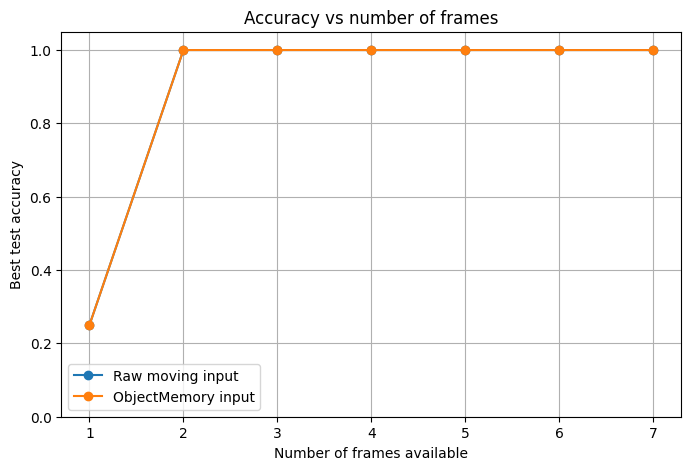

In [102]:
plt.figure(figsize=(8, 5))

plt.plot(
    frame_count_results["num_frames"],
    frame_count_results["raw_best_test_accuracy"],
    marker="o",
    label="Raw moving input",
)

plt.plot(
    frame_count_results["num_frames"],
    frame_count_results["memory_best_test_accuracy"],
    marker="o",
    label="ObjectMemory input",
)

plt.xlabel("Number of frames available")
plt.ylabel("Best test accuracy")
plt.title("Accuracy vs number of frames")
plt.ylim(0.0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

In [103]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF

import pandas as pd
import matplotlib.pyplot as plt

In [104]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [105]:
class FullySpikingMLPClassifier(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=256,
        num_classes=4,
        beta=0.9,
        threshold=1.0,
    ):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid(slope=25)

        # Trainable synapses into hidden spiking layer
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
        )

        # Trainable synapses into output spiking layer
        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.lif2 = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
        )

    def forward(self, spike_movie):
        """
        spike_movie shape: [batch, T, H, W]

        Returns:
            output_spike_counts shape: [batch, num_classes]
            output_spike_history shape: [T, batch, num_classes]
        """

        batch_size, num_steps, height, width = spike_movie.shape

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        output_spike_history = []

        for t in range(num_steps):
            x_t = spike_movie[:, t]              # [batch, H, W]
            x_t = x_t.flatten(start_dim=1)       # [batch, H*W]

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            output_spike_history.append(spk2)

        output_spike_history = torch.stack(output_spike_history, dim=0)
        output_spike_counts = output_spike_history.sum(dim=0)

        return output_spike_counts, output_spike_history

In [106]:
def compute_spiking_accuracy(model, data_loader, device):
    model.eval()

    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for spike_movies, batch_labels in data_loader:
            spike_movies = spike_movies.to(device)
            batch_labels = batch_labels.to(device)

            output_spike_counts, _ = model(spike_movies)

            predictions = output_spike_counts.argmax(dim=1)

            total_correct += (predictions == batch_labels).sum().item()
            total_examples += batch_labels.shape[0]

    return total_correct / total_examples

In [116]:
def train_fully_spiking_classifier(
    train_loader,
    test_loader,
    input_size,
    hidden_size=256,
    num_classes=4,
    num_epochs=50,
    learning_rate=1e-3,
    beta=0.9,
    threshold=1.0,
    device=device,
):
    model = FullySpikingMLPClassifier(
        input_size=input_size,
        hidden_size=hidden_size,
        num_classes=num_classes,
        beta=beta,
        threshold=threshold,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    loss_fn = SF.ce_count_loss()

    history = []

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_examples = 0

        for spike_movies, batch_labels in train_loader:
            spike_movies = spike_movies.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()

            output_spike_counts, output_spike_history = model(spike_movies)
            loss = loss_fn(output_spike_history, batch_labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_labels.shape[0]
            total_examples += batch_labels.shape[0]

        train_loss = total_loss / total_examples
        train_accuracy = compute_spiking_accuracy(model, train_loader, device)
        test_accuracy = compute_spiking_accuracy(model, test_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        })

        print(
            f"epoch {epoch:02d} | "
            f"loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.3f} | "
            f"test acc {test_accuracy:.3f}"
        )

    return model, pd.DataFrame(history)

In [117]:
def make_stratified_train_test_split(labels, train_fraction=0.8, seed=0):
    torch.manual_seed(seed)

    train_indices = []
    test_indices = []

    unique_labels = torch.unique(labels)

    for class_label in unique_labels:
        class_indices = torch.nonzero(labels == class_label, as_tuple=False).squeeze(1)
        shuffled_class_indices = class_indices[torch.randperm(class_indices.shape[0])]

        train_size = int(train_fraction * class_indices.shape[0])

        train_indices.append(shuffled_class_indices[:train_size])
        test_indices.append(shuffled_class_indices[train_size:])

    train_indices = torch.cat(train_indices)
    test_indices = torch.cat(test_indices)

    train_indices = train_indices[torch.randperm(train_indices.shape[0])]
    test_indices = test_indices[torch.randperm(test_indices.shape[0])]

    return train_indices, test_indices

In [118]:
train_indices, test_indices = make_stratified_train_test_split(
    labels=labels,
    train_fraction=0.8,
    seed=0,
)

raw_train_loader, raw_test_loader = make_dataloaders(
    raw_spikes_dataset,
    labels,
    train_indices,
    test_indices,
    batch_size=32,
)

memory_train_loader, memory_test_loader = make_dataloaders(
    object_memory_spikes_dataset,
    labels,
    train_indices,
    test_indices,
    batch_size=32,
)

In [119]:
height = raw_spikes_dataset.shape[2]
width = raw_spikes_dataset.shape[3]
input_size = height * width
num_classes = len(SHAPE_TO_LABEL)

raw_fully_spiking_model, raw_fully_spiking_history = train_fully_spiking_classifier(
    train_loader=raw_train_loader,
    test_loader=raw_test_loader,
    input_size=input_size,
    hidden_size=256,
    num_classes=num_classes,
    num_epochs=50,
    learning_rate=1e-3,
    beta=0.9,
    threshold=1.0,
    device=device,
)

epoch 00 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 01 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 02 | loss 1.3863 | train acc 0.256 | test acc 0.250
epoch 03 | loss 1.3391 | train acc 0.409 | test acc 0.312
epoch 04 | loss 1.1712 | train acc 0.478 | test acc 0.425
epoch 05 | loss 1.1620 | train acc 0.463 | test acc 0.412
epoch 06 | loss 1.0904 | train acc 0.500 | test acc 0.412
epoch 07 | loss 1.0470 | train acc 0.525 | test acc 0.438
epoch 08 | loss 0.9637 | train acc 0.600 | test acc 0.463
epoch 09 | loss 0.8282 | train acc 0.719 | test acc 0.388
epoch 10 | loss 0.6431 | train acc 0.812 | test acc 0.375
epoch 11 | loss 0.4937 | train acc 0.881 | test acc 0.325
epoch 12 | loss 0.3574 | train acc 0.897 | test acc 0.312
epoch 13 | loss 0.2949 | train acc 0.922 | test acc 0.312
epoch 14 | loss 0.2338 | train acc 0.938 | test acc 0.338
epoch 15 | loss 0.1919 | train acc 0.950 | test acc 0.312
epoch 16 | loss 0.1479 | train acc 0.966 | test acc 0.338
epoch 17 | los

In [120]:
memory_fully_spiking_model, memory_fully_spiking_history = train_fully_spiking_classifier(
    train_loader=memory_train_loader,
    test_loader=memory_test_loader,
    input_size=input_size,
    hidden_size=256,
    num_classes=num_classes,
    num_epochs=50,
    learning_rate=1e-3,
    beta=0.9,
    threshold=1.0,
    device=device,
)

epoch 00 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 01 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 02 | loss 1.3783 | train acc 0.347 | test acc 0.263
epoch 03 | loss 1.2191 | train acc 0.497 | test acc 0.362
epoch 04 | loss 1.0856 | train acc 0.516 | test acc 0.388
epoch 05 | loss 0.9788 | train acc 0.703 | test acc 0.400
epoch 06 | loss 0.5856 | train acc 0.931 | test acc 0.362
epoch 07 | loss 0.2677 | train acc 0.975 | test acc 0.375
epoch 08 | loss 0.1228 | train acc 0.981 | test acc 0.312
epoch 09 | loss 0.0789 | train acc 0.991 | test acc 0.312
epoch 10 | loss 0.0571 | train acc 0.994 | test acc 0.325
epoch 11 | loss 0.0427 | train acc 0.997 | test acc 0.350
epoch 12 | loss 0.0373 | train acc 0.997 | test acc 0.362
epoch 13 | loss 0.0326 | train acc 0.997 | test acc 0.350
epoch 14 | loss 0.0295 | train acc 1.000 | test acc 0.350
epoch 15 | loss 0.0262 | train acc 1.000 | test acc 0.350
epoch 16 | loss 0.0256 | train acc 1.000 | test acc 0.350
epoch 17 | los

In [113]:
fully_spiking_comparison = pd.DataFrame({
    "epoch": raw_fully_spiking_history["epoch"],
    "raw_train_accuracy": raw_fully_spiking_history["train_accuracy"],
    "raw_test_accuracy": raw_fully_spiking_history["test_accuracy"],
    "memory_train_accuracy": memory_fully_spiking_history["train_accuracy"],
    "memory_test_accuracy": memory_fully_spiking_history["test_accuracy"],
})

fully_spiking_comparison

,epoch,raw_train_accuracy,raw_test_accuracy,memory_train_accuracy,memory_test_accuracy
0,0,0.250000,0.2500,0.250000,0.2500
1,1,0.250000,0.2500,0.250000,0.2500
2,2,0.256250,0.2500,0.346875,0.2625
3,3,0.409375,0.3125,0.496875,0.3625
4,4,0.478125,0.4250,0.515625,0.3875
5,5,0.462500,0.4125,0.703125,0.4000
6,6,0.500000,0.4125,0.931250,0.3625
7,7,0.525000,0.4375,0.975000,0.3750
8,8,0.600000,0.4625,0.981250,0.3125
9,9,0.718750,0.3875,0.990625,0.3125


In [114]:
def inspect_fully_spiking_outputs(model, data_loader, device, num_batches=1):
    model.eval()

    with torch.no_grad():
        for batch_index, (spike_movies, batch_labels) in enumerate(data_loader):
            if batch_index >= num_batches:
                break

            spike_movies = spike_movies.to(device)
            batch_labels = batch_labels.to(device)

            output_spike_counts, output_spike_history = model(spike_movies)

            print("output_spike_counts shape:", output_spike_counts.shape)
            print("mean output spike count:", output_spike_counts.mean().item())
            print("max output spike count:", output_spike_counts.max().item())
            print("min output spike count:", output_spike_counts.min().item())
            print("total output spikes:", output_spike_counts.sum().item())

            print("\nFirst 10 output spike counts:")
            print(output_spike_counts[:10].cpu())

            print("\nFirst 10 labels:")
            print(batch_labels[:10].cpu())

            print("\nFirst 10 predictions:")
            print(output_spike_counts.argmax(dim=1)[:10].cpu())

In [115]:
inspect_fully_spiking_outputs(
    raw_fully_spiking_model,
    raw_test_loader,
    device,
)

inspect_fully_spiking_outputs(
    memory_fully_spiking_model,
    memory_test_loader,
    device,
)

output_spike_counts shape: torch.Size([32, 4])
mean output spike count: 1.265625
max output spike count: 6.0
min output spike count: 0.0
total output spikes: 162.0

First 10 output spike counts:
tensor([[0., 2., 0., 2.],
        [2., 0., 3., 0.],
        [0., 3., 5., 0.],
        [1., 0., 5., 0.],
        [0., 3., 1., 1.],
        [3., 0., 0., 1.],
        [3., 0., 1., 0.],
        [2., 0., 4., 1.],
        [1., 2., 0., 1.],
        [1., 3., 1., 0.]])

First 10 labels:
tensor([3, 0, 1, 3, 2, 3, 3, 0, 2, 0])

First 10 predictions:
tensor([1, 2, 2, 2, 1, 0, 0, 2, 1, 1])
output_spike_counts shape: torch.Size([32, 4])
mean output spike count: 0.8984375
max output spike count: 5.0
min output spike count: 0.0
total output spikes: 115.0

First 10 output spike counts:
tensor([[0., 0., 0., 2.],
        [1., 0., 4., 0.],
        [0., 0., 5., 0.],
        [0., 0., 4., 0.],
        [0., 2., 2., 0.],
        [0., 3., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 2., 0.],
        [0., 0., 3., 

In [121]:
class TutorialStyleSNN(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=1000,
        num_classes=4,
        beta=0.95,
    ):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid(slope=25)

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad,
        )

        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad,
        )

    def forward(self, spike_movie):
        """
        spike_movie shape: [batch, T, H, W]

        Returns:
            spk_rec: [T, batch, num_classes]
            mem_rec: [T, batch, num_classes]
        """

        batch_size, num_steps, height, width = spike_movie.shape

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk_rec = []
        mem_rec = []

        for t in range(num_steps):
            x_t = spike_movie[:, t].flatten(start_dim=1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk_rec.append(spk2)
            mem_rec.append(mem2)

        spk_rec = torch.stack(spk_rec, dim=0)
        mem_rec = torch.stack(mem_rec, dim=0)

        return spk_rec, mem_rec

In [122]:
def tutorial_style_loss(mem_rec, labels):
    """
    mem_rec shape: [T, batch, num_classes]
    labels shape: [batch]
    """

    loss = torch.zeros(1, device=mem_rec.device)

    for t in range(mem_rec.shape[0]):
        loss = loss + nn.CrossEntropyLoss()(mem_rec[t], labels)

    return loss

In [125]:
def tutorial_style_accuracy(model, data_loader, device):
    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():
        for spike_movies, labels_batch in data_loader:
            spike_movies = spike_movies.to(device)
            labels_batch = labels_batch.to(device)

            spk_rec, mem_rec = model(spike_movies)

            spike_counts = spk_rec.sum(dim=0)
            predictions = spike_counts.argmax(dim=1)

            correct += (predictions == labels_batch).sum().item()
            total += labels_batch.shape[0]

    return correct / total

In [127]:
def train_tutorial_style_snn(
    train_loader,
    test_loader,
    input_size,
    hidden_size=1000,
    num_classes=4,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    device=device,
):
    model = TutorialStyleSNN(
        input_size=input_size,
        hidden_size=hidden_size,
        num_classes=num_classes,
        beta=beta,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.999),
    )

    history = []

    best_test_accuracy = 0.0
    best_model_state = None
    best_epoch = 0

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_examples = 0

        for spike_movies, labels_batch in train_loader:
            spike_movies = spike_movies.to(device)
            labels_batch = labels_batch.to(device)

            optimizer.zero_grad()

            spk_rec, mem_rec = model(spike_movies)
            loss = tutorial_style_loss(mem_rec, labels_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels_batch.shape[0]
            total_examples += labels_batch.shape[0]

        train_loss = total_loss / total_examples
        train_accuracy = tutorial_style_accuracy(model, train_loader, device)
        test_accuracy = tutorial_style_accuracy(model, test_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        })

        if test_accuracy > best_test_accuracy:
            best_test_accuracy = test_accuracy
            best_epoch = epoch
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"epoch {epoch:02d} | "
            f"loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.3f} | "
            f"test acc {test_accuracy:.3f}"
        )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"Best test accuracy: {best_test_accuracy:.3f} at epoch {best_epoch}")

    return model, pd.DataFrame(history)

In [128]:
height = raw_spikes_dataset.shape[2]
width = raw_spikes_dataset.shape[3]
input_size = height * width
num_classes = len(SHAPE_TO_LABEL)

raw_tutorial_model, raw_tutorial_history = train_tutorial_style_snn(
    train_loader=raw_train_loader,
    test_loader=raw_test_loader,
    input_size=input_size,
    hidden_size=1000,
    num_classes=num_classes,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    device=device,
)

epoch 00 | loss 9.7180 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.7148 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7112 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.6304 | train acc 0.350 | test acc 0.275
epoch 04 | loss 9.1897 | train acc 0.487 | test acc 0.375
epoch 05 | loss 8.6266 | train acc 0.466 | test acc 0.412
epoch 06 | loss 8.3125 | train acc 0.475 | test acc 0.400
epoch 07 | loss 7.8609 | train acc 0.613 | test acc 0.388
epoch 08 | loss 7.2377 | train acc 0.803 | test acc 0.375
epoch 09 | loss 6.4947 | train acc 0.906 | test acc 0.338
epoch 10 | loss 5.7076 | train acc 0.941 | test acc 0.325
epoch 11 | loss 4.9600 | train acc 0.975 | test acc 0.300
epoch 12 | loss 4.3450 | train acc 0.991 | test acc 0.287
epoch 13 | loss 3.8935 | train acc 0.994 | test acc 0.300
epoch 14 | loss 3.5407 | train acc 1.000 | test acc 0.263
epoch 15 | loss 3.2627 | train acc 1.000 | test acc 0.275
epoch 16 | loss 3.0427 | train acc 1.000 | test acc 0.250
epoch 17 | los

In [129]:
memory_tutorial_model, memory_tutorial_history = train_tutorial_style_snn(
    train_loader=memory_train_loader,
    test_loader=memory_test_loader,
    input_size=input_size,
    hidden_size=1000,
    num_classes=num_classes,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    device=device,
)

epoch 00 | loss 9.7153 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.7134 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7079 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.6345 | train acc 0.306 | test acc 0.263
epoch 04 | loss 9.2598 | train acc 0.497 | test acc 0.338
epoch 05 | loss 8.6915 | train acc 0.519 | test acc 0.400
epoch 06 | loss 7.9586 | train acc 0.756 | test acc 0.400
epoch 07 | loss 6.8521 | train acc 0.966 | test acc 0.388
epoch 08 | loss 5.6640 | train acc 0.994 | test acc 0.350
epoch 09 | loss 4.7673 | train acc 0.997 | test acc 0.350
epoch 10 | loss 4.1602 | train acc 1.000 | test acc 0.350
epoch 11 | loss 3.8237 | train acc 1.000 | test acc 0.350
epoch 12 | loss 3.5992 | train acc 1.000 | test acc 0.325
epoch 13 | loss 3.3578 | train acc 1.000 | test acc 0.325
epoch 14 | loss 3.0679 | train acc 1.000 | test acc 0.312
epoch 15 | loss 2.8176 | train acc 1.000 | test acc 0.300
epoch 16 | loss 2.6371 | train acc 1.000 | test acc 0.312
epoch 17 | los

In [130]:
def get_frame_bounding_box(frame):
    """
    frame shape: [H, W]
    Returns bounding box of active pixels.
    """

    active = torch.nonzero(frame > 0, as_tuple=False)

    if active.numel() == 0:
        return {
            "has_activity": False,
            "y_min": None,
            "y_max": None,
            "x_min": None,
            "x_max": None,
            "height": 0,
            "width": 0,
            "center_y": None,
            "center_x": None,
            "active_pixels": 0,
        }

    y_min = int(active[:, 0].min().item())
    y_max = int(active[:, 0].max().item())
    x_min = int(active[:, 1].min().item())
    x_max = int(active[:, 1].max().item())

    center_y = float(active[:, 0].float().mean().item())
    center_x = float(active[:, 1].float().mean().item())

    return {
        "has_activity": True,
        "y_min": y_min,
        "y_max": y_max,
        "x_min": x_min,
        "x_max": x_max,
        "height": y_max - y_min + 1,
        "width": x_max - x_min + 1,
        "center_y": center_y,
        "center_x": center_x,
        "active_pixels": int(active.shape[0]),
    }

In [131]:
def summarize_movie_positions(spike_movie, label_name=None):
    """
    spike_movie shape: [T, H, W]
    """

    rows = []

    for t in range(spike_movie.shape[0]):
        bbox = get_frame_bounding_box(spike_movie[t])
        bbox["t"] = t
        if label_name is not None:
            bbox["label"] = label_name
        rows.append(bbox)

    table = pd.DataFrame(rows)

    columns = [
        "label",
        "t",
        "has_activity",
        "center_y",
        "center_x",
        "y_min",
        "y_max",
        "x_min",
        "x_max",
        "height",
        "width",
        "active_pixels",
    ]

    columns = [col for col in columns if col in table.columns]

    return table[columns]

In [132]:
sample_index = 0
true_shape = LABEL_TO_SHAPE[int(labels[sample_index].item())]

print("true shape:", true_shape)

raw_position_table = summarize_movie_positions(
    raw_spikes_dataset[sample_index],
    label_name=true_shape,
)

memory_position_table = summarize_movie_positions(
    object_memory_spikes_dataset[sample_index],
    label_name=true_shape,
)

print("Raw positions:")
display(raw_position_table)

print("ObjectMemory positions:")
display(memory_position_table)

true shape: seven
Raw positions:


,label,t,has_activity,center_y,center_x,y_min,y_max,x_min,x_max,height,width,active_pixels
0,seven,0,True,24.111111,38.888889,23,27,37,41,5,5,9
1,seven,1,True,25.111111,38.888889,24,28,37,41,5,5,9
2,seven,2,True,22.111111,37.888889,21,25,36,40,5,5,9
3,seven,3,True,20.111111,36.888889,19,23,35,39,5,5,9
4,seven,4,True,23.111111,36.888889,22,26,35,39,5,5,9
5,seven,5,True,24.111111,38.888889,23,27,37,41,5,5,9
6,seven,6,True,23.111111,35.888889,22,26,34,38,5,5,9


ObjectMemory positions:


,label,t,has_activity,center_y,center_x,y_min,y_max,x_min,x_max,height,width,active_pixels
0,seven,0,True,24.111111,38.888889,23,27,37,41,5,5,9
1,seven,1,True,24.111111,38.888889,23,27,37,41,5,5,9
2,seven,2,True,24.111111,38.888889,23,27,37,41,5,5,9
3,seven,3,True,24.111111,38.888889,23,27,37,41,5,5,9
4,seven,4,True,24.111111,38.888889,23,27,37,41,5,5,9
5,seven,5,True,24.111111,38.888889,23,27,37,41,5,5,9
6,seven,6,True,24.111111,38.888889,23,27,37,41,5,5,9


In [152]:
class ConvSpikingClassifier(nn.Module):
    def __init__(
        self,
        num_classes=4,
        beta=0.95,
        threshold=1.0,
        image_height=64,
        image_width=64,
    ):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid(slope=25)

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=12,
            kernel_size=5,
            stride=2,
            padding=2,
        )
        self.lif1 = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
        )

        self.conv2 = nn.Conv2d(
            in_channels=12,
            out_channels=24,
            kernel_size=5,
            stride=2,
            padding=2,
        )
        self.lif2 = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
        )

        # For 64x64:
        # conv1 stride 2 gives 32x32
        # conv2 stride 2 gives 16x16
        conv_height = image_height // 4
        conv_width = image_width // 4
        flattened_size = 24 * conv_height * conv_width

        self.fc1 = nn.Linear(flattened_size, 128)
        self.lif3 = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
        )

        self.fc_out = nn.Linear(128, num_classes)
        self.lif_out = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
        )

    def forward(self, spike_movie):
        """
        spike_movie shape: [batch, T, H, W]

        Returns:
            spk_rec: [T, batch, num_classes]
            mem_rec: [T, batch, num_classes]
        """

        batch_size, num_steps, height, width = spike_movie.shape

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_rec = []
        mem_rec = []

        for t in range(num_steps):
            x_t = spike_movie[:, t].unsqueeze(1)  # [batch, 1, H, W]

            cur1 = self.conv1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            flat = spk2.flatten(start_dim=1)

            cur3 = self.fc1(flat)
            spk3, mem3 = self.lif3(cur3, mem3)

            cur_out = self.fc_out(spk3)
            spk_out, mem_out = self.lif_out(cur_out, mem_out)

            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        spk_rec = torch.stack(spk_rec, dim=0)
        mem_rec = torch.stack(mem_rec, dim=0)

        return spk_rec, mem_rec

In [153]:
def conv_snn_accuracy(model, data_loader, device):
    model.eval()

    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for spike_movies, labels_batch in data_loader:
            spike_movies = spike_movies.to(device)
            labels_batch = labels_batch.to(device)

            spk_rec, mem_rec = model(spike_movies)

            # Count output spikes over time.
            spike_counts = spk_rec.sum(dim=0)  # [batch, num_classes]

            predictions = spike_counts.argmax(dim=1)

            total_correct += (predictions == labels_batch).sum().item()
            total_examples += labels_batch.shape[0]

    return total_correct / total_examples

In [154]:
def train_conv_spiking_classifier(
    train_loader,
    test_loader,
    num_classes=4,
    image_height=64,
    image_width=64,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1.0,
    device=device,
):
    model = ConvSpikingClassifier(
        num_classes=num_classes,
        beta=beta,
        threshold=threshold,
        image_height=image_height,
        image_width=image_width,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.999),
        weight_decay=1e-5,
    )

    loss_fn = nn.CrossEntropyLoss()

    history = []

    best_test_accuracy = 0.0
    best_epoch = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_examples = 0

        for spike_movies, labels_batch in train_loader:
            spike_movies = spike_movies.to(device)
            labels_batch = labels_batch.to(device)

            optimizer.zero_grad()

            spk_rec, mem_rec = model(spike_movies)

            # Tutorial-style loss:
            # use output membrane at each timestep for smoother gradients.
            loss = torch.zeros(1, device=device)

            for t in range(mem_rec.shape[0]):
                loss = loss + loss_fn(mem_rec[t], labels_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels_batch.shape[0]
            total_examples += labels_batch.shape[0]

        train_loss = total_loss / total_examples
        train_accuracy = conv_snn_accuracy(model, train_loader, device)
        test_accuracy = conv_snn_accuracy(model, test_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        })

        if test_accuracy > best_test_accuracy:
            best_test_accuracy = test_accuracy
            best_epoch = epoch
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"epoch {epoch:02d} | "
            f"loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.3f} | "
            f"test acc {test_accuracy:.3f}"
        )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"Best test accuracy: {best_test_accuracy:.3f} at epoch {best_epoch}")

    return model, pd.DataFrame(history)

In [157]:
height = raw_spikes_dataset.shape[2]
width = raw_spikes_dataset.shape[3]
num_classes = len(SHAPE_TO_LABEL)

raw_conv_snn_model, raw_conv_snn_history = train_conv_spiking_classifier(
    train_loader=raw_train_loader,
    test_loader=raw_test_loader,
    num_classes=num_classes,
    image_height=height,
    image_width=width,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1.0,
    device=device,
)

epoch 00 | loss 9.7564 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.7515 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7443 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.7392 | train acc 0.250 | test acc 0.250
epoch 04 | loss 9.7333 | train acc 0.250 | test acc 0.250
epoch 05 | loss 9.7262 | train acc 0.250 | test acc 0.250
epoch 06 | loss 9.7203 | train acc 0.250 | test acc 0.250
epoch 07 | loss 9.7200 | train acc 0.250 | test acc 0.250
epoch 08 | loss 9.7199 | train acc 0.250 | test acc 0.250
epoch 09 | loss 9.7177 | train acc 0.250 | test acc 0.250
epoch 10 | loss 9.7174 | train acc 0.250 | test acc 0.250
epoch 11 | loss 9.7161 | train acc 0.250 | test acc 0.250
epoch 12 | loss 9.7143 | train acc 0.250 | test acc 0.250
epoch 13 | loss 9.7093 | train acc 0.250 | test acc 0.250
epoch 14 | loss 9.6917 | train acc 0.250 | test acc 0.250
epoch 15 | loss 9.6822 | train acc 0.250 | test acc 0.250
epoch 16 | loss 9.6703 | train acc 0.250 | test acc 0.250
epoch 17 | los

In [158]:
memory_conv_snn_model, memory_conv_snn_history = train_conv_spiking_classifier(
    train_loader=memory_train_loader,
    test_loader=memory_test_loader,
    num_classes=num_classes,
    image_height=height,
    image_width=width,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1,
    device=device,
)

epoch 00 | loss 9.7519 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.7446 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7412 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.7368 | train acc 0.250 | test acc 0.250
epoch 04 | loss 9.7327 | train acc 0.250 | test acc 0.250
epoch 05 | loss 9.7299 | train acc 0.250 | test acc 0.250
epoch 06 | loss 9.6355 | train acc 0.391 | test acc 0.362
epoch 07 | loss 9.3560 | train acc 0.412 | test acc 0.400
epoch 08 | loss 9.1784 | train acc 0.466 | test acc 0.450
epoch 09 | loss 9.0093 | train acc 0.466 | test acc 0.450
epoch 10 | loss 8.8675 | train acc 0.478 | test acc 0.463
epoch 11 | loss 8.7130 | train acc 0.487 | test acc 0.463
epoch 12 | loss 8.5713 | train acc 0.497 | test acc 0.463
epoch 13 | loss 8.4244 | train acc 0.509 | test acc 0.450
epoch 14 | loss 8.2739 | train acc 0.550 | test acc 0.500
epoch 15 | loss 8.1125 | train acc 0.559 | test acc 0.438
epoch 16 | loss 7.9329 | train acc 0.594 | test acc 0.463
epoch 17 | los

In [159]:
import random
import numpy as np
import torch

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [160]:
set_all_seeds(0)

raw_conv_snn_model_seed0, raw_conv_snn_history_seed0 = train_conv_spiking_classifier(
    train_loader=raw_train_loader,
    test_loader=raw_test_loader,
    num_classes=num_classes,
    image_height=height,
    image_width=width,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1.0,
    device=device,
)

epoch 00 | loss 9.8206 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.8057 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7950 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.7814 | train acc 0.250 | test acc 0.250
epoch 04 | loss 9.7720 | train acc 0.250 | test acc 0.250
epoch 05 | loss 9.7640 | train acc 0.250 | test acc 0.250
epoch 06 | loss 9.7566 | train acc 0.250 | test acc 0.250
epoch 07 | loss 9.7491 | train acc 0.250 | test acc 0.250
epoch 08 | loss 9.7431 | train acc 0.250 | test acc 0.250
epoch 09 | loss 9.7384 | train acc 0.250 | test acc 0.250
epoch 10 | loss 9.7339 | train acc 0.250 | test acc 0.250
epoch 11 | loss 9.7305 | train acc 0.250 | test acc 0.250
epoch 12 | loss 9.7285 | train acc 0.250 | test acc 0.250
epoch 13 | loss 9.7242 | train acc 0.250 | test acc 0.250
epoch 14 | loss 9.7210 | train acc 0.250 | test acc 0.250
epoch 15 | loss 9.7194 | train acc 0.250 | test acc 0.250
epoch 16 | loss 9.7170 | train acc 0.250 | test acc 0.250
epoch 17 | los

In [161]:
set_all_seeds(0)

memory_conv_snn_model_seed0, memory_conv_snn_history_seed0 = train_conv_spiking_classifier(
    train_loader=memory_train_loader,
    test_loader=memory_test_loader,
    num_classes=num_classes,
    image_height=height,
    image_width=width,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1.0,
    device=device,
)

epoch 00 | loss 9.8206 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.8057 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7950 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.7814 | train acc 0.250 | test acc 0.250
epoch 04 | loss 9.7720 | train acc 0.250 | test acc 0.250
epoch 05 | loss 9.7640 | train acc 0.250 | test acc 0.250
epoch 06 | loss 9.7566 | train acc 0.250 | test acc 0.250
epoch 07 | loss 9.7491 | train acc 0.250 | test acc 0.250
epoch 08 | loss 9.7431 | train acc 0.250 | test acc 0.250
epoch 09 | loss 9.7384 | train acc 0.250 | test acc 0.250
epoch 10 | loss 9.7339 | train acc 0.250 | test acc 0.250
epoch 11 | loss 9.7305 | train acc 0.250 | test acc 0.250
epoch 12 | loss 9.7285 | train acc 0.250 | test acc 0.250
epoch 13 | loss 9.7242 | train acc 0.250 | test acc 0.250
epoch 14 | loss 9.7210 | train acc 0.250 | test acc 0.250
epoch 15 | loss 9.7194 | train acc 0.250 | test acc 0.250
epoch 16 | loss 9.7170 | train acc 0.250 | test acc 0.250
epoch 17 | los

In [162]:
def best_test_accuracy(history):
    return history["test_accuracy"].max()

In [163]:
seed_results = []

for seed in [0, 1, 2, 3, 4]:
    print(f"\nSeed {seed} raw")

    set_all_seeds(seed)
    raw_model, raw_history = train_conv_spiking_classifier(
        train_loader=raw_train_loader,
        test_loader=raw_test_loader,
        num_classes=num_classes,
        image_height=height,
        image_width=width,
        num_epochs=50,
        learning_rate=5e-4,
        beta=0.95,
        threshold=1.0,
        device=device,
    )

    print(f"\nSeed {seed} memory")

    set_all_seeds(seed)
    memory_model, memory_history = train_conv_spiking_classifier(
        train_loader=memory_train_loader,
        test_loader=memory_test_loader,
        num_classes=num_classes,
        image_height=height,
        image_width=width,
        num_epochs=50,
        learning_rate=5e-4,
        beta=0.95,
        threshold=1.0,
        device=device,
    )

    seed_results.append({
        "seed": seed,
        "raw_best_test": best_test_accuracy(raw_history),
        "memory_best_test": best_test_accuracy(memory_history),
        "raw_final_test": raw_history["test_accuracy"].iloc[-1],
        "memory_final_test": memory_history["test_accuracy"].iloc[-1],
    })

seed_results_df = pd.DataFrame(seed_results)
seed_results_df


Seed 0 raw
epoch 00 | loss 9.8206 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.8057 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7950 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.7814 | train acc 0.250 | test acc 0.250
epoch 04 | loss 9.7720 | train acc 0.250 | test acc 0.250
epoch 05 | loss 9.7640 | train acc 0.250 | test acc 0.250
epoch 06 | loss 9.7566 | train acc 0.250 | test acc 0.250
epoch 07 | loss 9.7491 | train acc 0.250 | test acc 0.250
epoch 08 | loss 9.7431 | train acc 0.250 | test acc 0.250
epoch 09 | loss 9.7384 | train acc 0.250 | test acc 0.250
epoch 10 | loss 9.7339 | train acc 0.250 | test acc 0.250
epoch 11 | loss 9.7305 | train acc 0.250 | test acc 0.250
epoch 12 | loss 9.7285 | train acc 0.250 | test acc 0.250
epoch 13 | loss 9.7242 | train acc 0.250 | test acc 0.250
epoch 14 | loss 9.7210 | train acc 0.250 | test acc 0.250
epoch 15 | loss 9.7194 | train acc 0.250 | test acc 0.250
epoch 16 | loss 9.7170 | train acc 0.250 | test acc 0.250
ep

,seed,raw_best_test,memory_best_test,raw_final_test,memory_final_test
0,0,0.2500,0.2500,0.250,0.2500
1,1,0.2500,0.5000,0.250,0.4500
2,2,0.2500,0.6625,0.250,0.6625
3,3,0.2500,0.2500,0.250,0.2500
4,4,0.4875,0.5500,0.475,0.4875


In [165]:
def get_predictions_and_labels(model, data_loader, device):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for spike_movies, labels_batch in data_loader:
            spike_movies = spike_movies.to(device)
            labels_batch = labels_batch.to(device)

            spk_rec, mem_rec = model(spike_movies)

            spike_counts = spk_rec.sum(dim=0)
            predictions = spike_counts.argmax(dim=1)

            all_predictions.append(predictions.cpu())
            all_labels.append(labels_batch.cpu())

    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    return all_predictions, all_labels

In [172]:
def prediction_histogram(
    model,
    data_loader,
    device,
    num_classes,
    label_to_shape,
):
    predictions, true_labels = get_predictions_and_labels(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    pred_counts = torch.bincount(
        predictions,
        minlength=num_classes,
    )

    true_counts = torch.bincount(
        true_labels,
        minlength=num_classes,
    )

    return pd.DataFrame({
        "class_index": list(range(num_classes)),
        "class_name": [
            label_to_shape[i]
            for i in range(num_classes)
        ],
        "true_count": true_counts.numpy(),
        "predicted_count": pred_counts.numpy(),
    })

In [167]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 26.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 34.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [173]:
from sklearn.metrics import confusion_matrix

def confusion_matrix_df(model, data_loader, device, num_classes, label_to_shape):
    predictions, true_labels = get_predictions_and_labels(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    cm = confusion_matrix(
        true_labels.numpy(),
        predictions.numpy(),
        labels=list(range(num_classes)),
    )

    class_names = [label_to_shape[i] for i in range(num_classes)]

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{name}" for name in class_names],
        columns=[f"pred_{name}" for name in class_names],
    )

    return cm_df

In [169]:
set_all_seeds(2)

memory_model_seed2, memory_history_seed2 = train_conv_spiking_classifier(
    train_loader=memory_train_loader,
    test_loader=memory_test_loader,
    num_classes=num_classes,
    image_height=height,
    image_width=width,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1.0,
    device=device,
)

epoch 00 | loss 9.7610 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.7543 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7506 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.7443 | train acc 0.250 | test acc 0.250
epoch 04 | loss 9.7405 | train acc 0.250 | test acc 0.250
epoch 05 | loss 9.7366 | train acc 0.250 | test acc 0.250
epoch 06 | loss 9.7306 | train acc 0.250 | test acc 0.250
epoch 07 | loss 9.7315 | train acc 0.250 | test acc 0.250
epoch 08 | loss 9.7266 | train acc 0.250 | test acc 0.250
epoch 09 | loss 9.7243 | train acc 0.250 | test acc 0.250
epoch 10 | loss 9.7224 | train acc 0.250 | test acc 0.250
epoch 11 | loss 9.7197 | train acc 0.250 | test acc 0.250
epoch 12 | loss 9.7173 | train acc 0.250 | test acc 0.250
epoch 13 | loss 9.6876 | train acc 0.250 | test acc 0.250
epoch 14 | loss 9.5835 | train acc 0.256 | test acc 0.250
epoch 15 | loss 9.4822 | train acc 0.300 | test acc 0.287
epoch 16 | loss 9.3432 | train acc 0.316 | test acc 0.275
epoch 17 | los

In [170]:
set_all_seeds(3)

memory_model_seed3, memory_history_seed3 = train_conv_spiking_classifier(
    train_loader=memory_train_loader,
    test_loader=memory_test_loader,
    num_classes=num_classes,
    image_height=height,
    image_width=width,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1.0,
    device=device,
)

epoch 00 | loss 9.7704 | train acc 0.250 | test acc 0.250
epoch 01 | loss 9.7640 | train acc 0.250 | test acc 0.250
epoch 02 | loss 9.7570 | train acc 0.250 | test acc 0.250
epoch 03 | loss 9.7503 | train acc 0.250 | test acc 0.250
epoch 04 | loss 9.7462 | train acc 0.250 | test acc 0.250
epoch 05 | loss 9.7412 | train acc 0.250 | test acc 0.250
epoch 06 | loss 9.7360 | train acc 0.250 | test acc 0.250
epoch 07 | loss 9.7324 | train acc 0.250 | test acc 0.250
epoch 08 | loss 9.7303 | train acc 0.250 | test acc 0.250
epoch 09 | loss 9.7261 | train acc 0.250 | test acc 0.250
epoch 10 | loss 9.7233 | train acc 0.250 | test acc 0.250
epoch 11 | loss 9.7210 | train acc 0.250 | test acc 0.250
epoch 12 | loss 9.7194 | train acc 0.250 | test acc 0.250
epoch 13 | loss 9.7175 | train acc 0.250 | test acc 0.250
epoch 14 | loss 9.7151 | train acc 0.250 | test acc 0.250
epoch 15 | loss 9.7140 | train acc 0.250 | test acc 0.250
epoch 16 | loss 9.7126 | train acc 0.250 | test acc 0.250
epoch 17 | los

In [174]:
print("Good seed 2 prediction histogram:")
display(
    prediction_histogram(
        model=memory_model_seed2,
        data_loader=memory_test_loader,
        device=device,
        num_classes=num_classes,
        label_to_shape=LABEL_TO_SHAPE,
    )
)

print("Bad seed 3 prediction histogram:")
display(
    prediction_histogram(
        model=memory_model_seed3,
        data_loader=memory_test_loader,
        device=device,
        num_classes=num_classes,
        label_to_shape=LABEL_TO_SHAPE,
    )
)

Good seed 2 prediction histogram:


,class_index,class_name,true_count,predicted_count
0,0,seven,20,36
1,1,box,20,18
2,2,tee,20,13
3,3,ell,20,13


Bad seed 3 prediction histogram:


,class_index,class_name,true_count,predicted_count
0,0,seven,20,80
1,1,box,20,0
2,2,tee,20,0
3,3,ell,20,0


In [175]:
print("Good seed 2 confusion matrix:")
display(
    confusion_matrix_df(
        model=memory_model_seed2,
        data_loader=memory_test_loader,
        device=device,
        num_classes=num_classes,
        label_to_shape=LABEL_TO_SHAPE,
    )
)

print("Bad seed 3 confusion matrix:")
display(
    confusion_matrix_df(
        model=memory_model_seed3,
        data_loader=memory_test_loader,
        device=device,
        num_classes=num_classes,
        label_to_shape=LABEL_TO_SHAPE,
    )
)

Good seed 2 confusion matrix:


,pred_seven,pred_box,pred_tee,pred_ell
true_seven,19,0,0,1
true_box,0,18,1,1
true_tee,9,0,8,3
true_ell,8,0,4,8


Bad seed 3 confusion matrix:


,pred_seven,pred_box,pred_tee,pred_ell
true_seven,20,0,0,0
true_box,20,0,0,0
true_tee,20,0,0,0
true_ell,20,0,0,0


In [176]:
import copy
import pandas as pd
import torch
import snntorch.functional as SF


def train_conv_spiking_classifier(
    train_loader,
    test_loader,
    num_classes=4,
    image_height=64,
    image_width=64,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1.0,
    device=device,
):
    """
    Train ConvSpikingClassifier using output spike-count loss.

    Predictions are based on the output neuron that produces the
    largest total number of spikes over all timesteps.
    """

    model = ConvSpikingClassifier(
        num_classes=num_classes,
        beta=beta,
        threshold=threshold,
        image_height=image_height,
        image_width=image_width,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.999),
        weight_decay=1e-5,
    )

    # Designed for multiclass classification from output spike counts.
    loss_fn = SF.ce_count_loss()

    history = []

    best_test_accuracy = -1.0
    best_train_accuracy = 0.0
    best_epoch = -1
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for spike_movies, labels_batch in train_loader:
            spike_movies = spike_movies.to(device)
            labels_batch = labels_batch.to(device)

            optimizer.zero_grad()

            # spk_rec shape: [T, batch, num_classes]
            spk_rec, mem_rec = model(spike_movies)

            # Loss compares accumulated output-spike activity by class.
            loss = loss_fn(spk_rec, labels_batch)

            loss.backward()
            optimizer.step()

            batch_size = labels_batch.shape[0]
            total_loss += loss.item() * batch_size
            total_examples += batch_size

            # Training predictions from output spike counts.
            spike_counts = spk_rec.detach().sum(dim=0)
            predictions = spike_counts.argmax(dim=1)

            total_correct += (
                predictions == labels_batch
            ).sum().item()

        train_loss = total_loss / total_examples
        train_accuracy = total_correct / total_examples

        test_accuracy = conv_snn_accuracy(
            model=model,
            data_loader=test_loader,
            device=device,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        })

        if test_accuracy > best_test_accuracy:
            best_test_accuracy = test_accuracy
            best_train_accuracy = train_accuracy
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"epoch {epoch:03d} | "
            f"loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.3f} | "
            f"test acc {test_accuracy:.3f}"
        )

    # Restore the best-performing test checkpoint.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print()
    print(
        f"Best test accuracy: {best_test_accuracy:.4f} "
        f"at epoch {best_epoch}"
    )
    print(
        f"Train accuracy at best epoch: "
        f"{best_train_accuracy:.4f}"
    )

    history_df = pd.DataFrame(history)

    return model, history_df

In [177]:
seed_results_count_loss = []

for seed in [0, 1, 2, 3, 4]:
    print(f"\n{'=' * 60}")
    print(f"Seed {seed}: raw input")
    print(f"{'=' * 60}")

    set_all_seeds(seed)

    raw_model, raw_history = train_conv_spiking_classifier(
        train_loader=raw_train_loader,
        test_loader=raw_test_loader,
        num_classes=num_classes,
        image_height=height,
        image_width=width,
        num_epochs=50,
        learning_rate=5e-4,
        beta=0.95,
        threshold=1.0,
        device=device,
    )

    print(f"\n{'=' * 60}")
    print(f"Seed {seed}: ObjectMemory input")
    print(f"{'=' * 60}")

    set_all_seeds(seed)

    memory_model, memory_history = train_conv_spiking_classifier(
        train_loader=memory_train_loader,
        test_loader=memory_test_loader,
        num_classes=num_classes,
        image_height=height,
        image_width=width,
        num_epochs=50,
        learning_rate=5e-4,
        beta=0.95,
        threshold=1.0,
        device=device,
    )

    seed_results_count_loss.append({
        "seed": seed,

        "raw_best_test": raw_history["test_accuracy"].max(),
        "memory_best_test": memory_history["test_accuracy"].max(),

        "raw_final_test": raw_history["test_accuracy"].iloc[-1],
        "memory_final_test": memory_history["test_accuracy"].iloc[-1],

        "raw_best_epoch": int(
            raw_history["test_accuracy"].idxmax()
        ),
        "memory_best_epoch": int(
            memory_history["test_accuracy"].idxmax()
        ),
    })

seed_results_count_loss_df = pd.DataFrame(
    seed_results_count_loss
)

seed_results_count_loss_df


Seed 0: raw input
epoch 000 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 001 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 002 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 003 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 004 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 005 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 006 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 007 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 008 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 009 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 010 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 011 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 012 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 013 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 014 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 015 | loss 1.3863 | train acc 0.250 | test acc 0.250
epoch 016 | loss 1.3863 | train acc 0

,seed,raw_best_test,memory_best_test,raw_final_test,memory_final_test,raw_best_epoch,memory_best_epoch
0,0,0.25,0.25,0.25,0.25,0,0
1,1,0.25,0.25,0.25,0.25,0,0
2,2,0.25,0.25,0.25,0.25,0,0
3,3,0.25,0.25,0.25,0.25,0,0
4,4,0.25,0.25,0.25,0.25,0,0


In [178]:
seed_results_count_loss_df["memory_minus_raw_best"] = (
    seed_results_count_loss_df["memory_best_test"]
    - seed_results_count_loss_df["raw_best_test"]
)

seed_results_count_loss_df["memory_minus_raw_final"] = (
    seed_results_count_loss_df["memory_final_test"]
    - seed_results_count_loss_df["raw_final_test"]
)

seed_results_count_loss_df

,seed,raw_best_test,memory_best_test,raw_final_test,memory_final_test,raw_best_epoch,memory_best_epoch,memory_minus_raw_best,memory_minus_raw_final
0,0,0.25,0.25,0.25,0.25,0,0,0.0,0.0
1,1,0.25,0.25,0.25,0.25,0,0,0.0,0.0
2,2,0.25,0.25,0.25,0.25,0,0,0.0,0.0
3,3,0.25,0.25,0.25,0.25,0,0,0.0,0.0
4,4,0.25,0.25,0.25,0.25,0,0,0.0,0.0


In [179]:
summary_columns = [
    "raw_best_test",
    "memory_best_test",
    "raw_final_test",
    "memory_final_test",
    "memory_minus_raw_best",
    "memory_minus_raw_final",
]

print("Mean:")
display(
    seed_results_count_loss_df[summary_columns]
    .mean()
    .to_frame("mean")
)

print("Standard deviation:")
display(
    seed_results_count_loss_df[summary_columns]
    .std()
    .to_frame("std")
)

Mean:


,mean
raw_best_test,0.25
memory_best_test,0.25
raw_final_test,0.25
memory_final_test,0.25
memory_minus_raw_best,0.00
memory_minus_raw_final,0.00


Standard deviation:


,std
raw_best_test,0.0
memory_best_test,0.0
raw_final_test,0.0
memory_final_test,0.0
memory_minus_raw_best,0.0
memory_minus_raw_final,0.0


In [180]:
import copy
import pandas as pd
import torch
import torch.nn as nn


def train_conv_spiking_classifier(
    train_loader,
    test_loader,
    num_classes=4,
    image_height=64,
    image_width=64,
    num_epochs=50,
    learning_rate=5e-4,
    beta=0.95,
    threshold=1.0,
    loss_start_timestep=3,
    device=device,
):
    """
    Train the convolutional SNN using output membrane-potential loss.

    The loss is applied only from loss_start_timestep onward. For a
    7-frame sequence and loss_start_timestep=3, timesteps 3, 4, 5, and 6
    contribute to the loss.

    Classification accuracy is still measured using output spike counts.
    """

    model = ConvSpikingClassifier(
        num_classes=num_classes,
        beta=beta,
        threshold=threshold,
        image_height=image_height,
        image_width=image_width,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.999),
        weight_decay=1e-5,
    )

    loss_fn = nn.CrossEntropyLoss()

    history = []

    best_test_accuracy = -1.0
    best_train_accuracy = 0.0
    best_epoch = -1
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for spike_movies, labels_batch in train_loader:
            spike_movies = spike_movies.to(device)
            labels_batch = labels_batch.to(device)

            optimizer.zero_grad()

            spk_rec, mem_rec = model(spike_movies)

            num_steps = mem_rec.shape[0]

            start_t = min(
                loss_start_timestep,
                num_steps - 1,
            )

            loss = torch.zeros(
                (),
                device=device,
            )

            for t in range(start_t, num_steps):
                loss = loss + loss_fn(
                    mem_rec[t],
                    labels_batch,
                )

            # Average across contributing timesteps so changing start_t
            # does not automatically change the loss scale.
            loss = loss / (num_steps - start_t)

            loss.backward()
            optimizer.step()

            batch_size = labels_batch.shape[0]

            total_loss += loss.item() * batch_size
            total_examples += batch_size

            spike_counts = spk_rec.detach().sum(dim=0)
            predictions = spike_counts.argmax(dim=1)

            total_correct += (
                predictions == labels_batch
            ).sum().item()

        train_loss = total_loss / total_examples
        train_accuracy = total_correct / total_examples

        test_accuracy = conv_snn_accuracy(
            model=model,
            data_loader=test_loader,
            device=device,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        })

        if test_accuracy > best_test_accuracy:
            best_test_accuracy = test_accuracy
            best_train_accuracy = train_accuracy
            best_epoch = epoch
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"epoch {epoch:03d} | "
            f"loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.3f} | "
            f"test acc {test_accuracy:.3f}"
        )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print()
    print(
        f"Best test accuracy: {best_test_accuracy:.4f} "
        f"at epoch {best_epoch}"
    )
    print(
        f"Train accuracy at best epoch: "
        f"{best_train_accuracy:.4f}"
    )

    return model, pd.DataFrame(history)

In [181]:
seed_results_count_loss = []

for seed in [0, 1, 2, 3, 4]:
    print(f"\n{'=' * 60}")
    print(f"Seed {seed}: raw input")
    print(f"{'=' * 60}")

    set_all_seeds(seed)

    raw_model, raw_history = train_conv_spiking_classifier(
        train_loader=raw_train_loader,
        test_loader=raw_test_loader,
        num_classes=num_classes,
        image_height=height,
        image_width=width,
        num_epochs=50,
        learning_rate=5e-4,
        beta=0.95,
        threshold=1.0,
        device=device,
    )

    print(f"\n{'=' * 60}")
    print(f"Seed {seed}: ObjectMemory input")
    print(f"{'=' * 60}")

    set_all_seeds(seed)

    memory_model, memory_history = train_conv_spiking_classifier(
        train_loader=memory_train_loader,
        test_loader=memory_test_loader,
        num_classes=num_classes,
        image_height=height,
        image_width=width,
        num_epochs=50,
        learning_rate=5e-4,
        beta=0.95,
        threshold=1.0,
        device=device,
    )

    seed_results_count_loss.append({
        "seed": seed,

        "raw_best_test": raw_history["test_accuracy"].max(),
        "memory_best_test": memory_history["test_accuracy"].max(),

        "raw_final_test": raw_history["test_accuracy"].iloc[-1],
        "memory_final_test": memory_history["test_accuracy"].iloc[-1],

        "raw_best_epoch": int(
            raw_history["test_accuracy"].idxmax()
        ),
        "memory_best_epoch": int(
            memory_history["test_accuracy"].idxmax()
        ),
    })

seed_results_count_loss_df = pd.DataFrame(
    seed_results_count_loss
)

seed_results_count_loss_df


Seed 0: raw input
epoch 000 | loss 1.4119 | train acc 0.250 | test acc 0.250
epoch 001 | loss 1.4086 | train acc 0.250 | test acc 0.250
epoch 002 | loss 1.4063 | train acc 0.250 | test acc 0.250
epoch 003 | loss 1.4036 | train acc 0.250 | test acc 0.250
epoch 004 | loss 1.4016 | train acc 0.250 | test acc 0.250
epoch 005 | loss 1.3997 | train acc 0.250 | test acc 0.250
epoch 006 | loss 1.3981 | train acc 0.250 | test acc 0.250
epoch 007 | loss 1.3965 | train acc 0.250 | test acc 0.250
epoch 008 | loss 1.3953 | train acc 0.250 | test acc 0.250
epoch 009 | loss 1.3941 | train acc 0.250 | test acc 0.250
epoch 010 | loss 1.3930 | train acc 0.250 | test acc 0.250
epoch 011 | loss 1.3920 | train acc 0.250 | test acc 0.250
epoch 012 | loss 1.3913 | train acc 0.250 | test acc 0.250
epoch 013 | loss 1.3909 | train acc 0.250 | test acc 0.250
epoch 014 | loss 1.3900 | train acc 0.250 | test acc 0.250
epoch 015 | loss 1.3895 | train acc 0.250 | test acc 0.250
epoch 016 | loss 1.3890 | train acc 0

,seed,raw_best_test,memory_best_test,raw_final_test,memory_final_test,raw_best_epoch,memory_best_epoch
0,0,0.25,0.2500,0.25,0.250,0,0
1,1,0.25,0.5375,0.25,0.475,0,23
2,2,0.25,0.2500,0.25,0.250,0,0
3,3,0.25,0.2500,0.25,0.250,0,0
4,4,0.25,0.5875,0.25,0.525,0,19


In [182]:
def compare_spike_and_membrane_predictions(
    model,
    data_loader,
    device,
    num_classes,
    label_to_shape,
):
    model.eval()

    all_labels = []
    all_spike_predictions = []
    all_membrane_predictions = []
    all_spike_counts = []
    all_membrane_scores = []

    with torch.no_grad():
        for spike_movies, labels_batch in data_loader:
            spike_movies = spike_movies.to(device)
            labels_batch = labels_batch.to(device)

            spk_rec, mem_rec = model(spike_movies)

            # Classification using output spike counts.
            spike_counts = spk_rec.sum(dim=0)

            # Diagnostic classification using accumulated membrane values.
            membrane_scores = mem_rec.sum(dim=0)

            spike_predictions = spike_counts.argmax(dim=1)
            membrane_predictions = membrane_scores.argmax(dim=1)

            all_labels.append(labels_batch.cpu())
            all_spike_predictions.append(spike_predictions.cpu())
            all_membrane_predictions.append(membrane_predictions.cpu())
            all_spike_counts.append(spike_counts.cpu())
            all_membrane_scores.append(membrane_scores.cpu())

    labels_all = torch.cat(all_labels)
    spike_predictions_all = torch.cat(all_spike_predictions)
    membrane_predictions_all = torch.cat(all_membrane_predictions)
    spike_counts_all = torch.cat(all_spike_counts)
    membrane_scores_all = torch.cat(all_membrane_scores)

    spike_accuracy = (
        spike_predictions_all == labels_all
    ).float().mean().item()

    membrane_accuracy = (
        membrane_predictions_all == labels_all
    ).float().mean().item()

    spike_prediction_counts = torch.bincount(
        spike_predictions_all,
        minlength=num_classes,
    )

    membrane_prediction_counts = torch.bincount(
        membrane_predictions_all,
        minlength=num_classes,
    )

    total_spikes_per_sample = spike_counts_all.sum(dim=1)

    summary_df = pd.DataFrame({
        "class_index": range(num_classes),
        "class_name": [
            label_to_shape[i]
            for i in range(num_classes)
        ],
        "spike_predictions": spike_prediction_counts.numpy(),
        "membrane_predictions": membrane_prediction_counts.numpy(),
    })

    print(f"Spike-count accuracy: {spike_accuracy:.4f}")
    print(f"Membrane-score accuracy: {membrane_accuracy:.4f}")

    print()
    print(
        "Samples with zero output spikes:",
        int((total_spikes_per_sample == 0).sum().item()),
        "/",
        len(total_spikes_per_sample),
    )

    print(
        "Mean total output spikes per sample:",
        total_spikes_per_sample.float().mean().item(),
    )

    print(
        "Maximum total output spikes for one sample:",
        total_spikes_per_sample.max().item(),
    )

    display(summary_df)

    return {
        "labels": labels_all,
        "spike_predictions": spike_predictions_all,
        "membrane_predictions": membrane_predictions_all,
        "spike_counts": spike_counts_all,
        "membrane_scores": membrane_scores_all,
        "summary": summary_df,
    }

In [183]:
bad_seed_diagnostic = compare_spike_and_membrane_predictions(
    model=memory_model_seed3,
    data_loader=memory_test_loader,
    device=device,
    num_classes=num_classes,
    label_to_shape=LABEL_TO_SHAPE,
)

Spike-count accuracy: 0.2500
Membrane-score accuracy: 0.2500

Samples with zero output spikes: 80 / 80
Mean total output spikes per sample: 0.0
Maximum total output spikes for one sample: 0.0


,class_index,class_name,spike_predictions,membrane_predictions
0,0,seven,80,0
1,1,box,0,80
2,2,tee,0,0
3,3,ell,0,0


In [184]:
good_seed_diagnostic = compare_spike_and_membrane_predictions(
    model=memory_model_seed2,
    data_loader=memory_test_loader,
    device=device,
    num_classes=num_classes,
    label_to_shape=LABEL_TO_SHAPE,
)

Spike-count accuracy: 0.6625
Membrane-score accuracy: 0.6875

Samples with zero output spikes: 36 / 80
Mean total output spikes per sample: 1.375
Maximum total output spikes for one sample: 6.0


,class_index,class_name,spike_predictions,membrane_predictions
0,0,seven,36,18
1,1,box,18,17
2,2,tee,13,20
3,3,ell,13,25


In [185]:
late_loss_memory_models = {}
late_loss_memory_histories = {}

seed_results_late_loss = []

for seed in [0, 1, 2, 3, 4]:
    set_all_seeds(seed)

    memory_model, memory_history = train_conv_spiking_classifier(
        train_loader=memory_train_loader,
        test_loader=memory_test_loader,
        num_classes=num_classes,
        image_height=height,
        image_width=width,
        num_epochs=50,
        learning_rate=5e-4,
        beta=0.95,
        threshold=1.0,
        loss_start_timestep=3,
        device=device,
    )

    late_loss_memory_models[seed] = memory_model
    late_loss_memory_histories[seed] = memory_history

    seed_results_late_loss.append({
        "seed": seed,
        "memory_best_test": memory_history["test_accuracy"].max(),
        "memory_final_test": memory_history["test_accuracy"].iloc[-1],
        "memory_best_epoch": int(
            memory_history["test_accuracy"].idxmax()
        ),
    })

epoch 000 | loss 1.4119 | train acc 0.250 | test acc 0.250
epoch 001 | loss 1.4086 | train acc 0.250 | test acc 0.250
epoch 002 | loss 1.4063 | train acc 0.250 | test acc 0.250
epoch 003 | loss 1.4036 | train acc 0.250 | test acc 0.250
epoch 004 | loss 1.4016 | train acc 0.250 | test acc 0.250
epoch 005 | loss 1.3997 | train acc 0.250 | test acc 0.250
epoch 006 | loss 1.3981 | train acc 0.250 | test acc 0.250
epoch 007 | loss 1.3965 | train acc 0.250 | test acc 0.250
epoch 008 | loss 1.3953 | train acc 0.250 | test acc 0.250
epoch 009 | loss 1.3941 | train acc 0.250 | test acc 0.250
epoch 010 | loss 1.3930 | train acc 0.250 | test acc 0.250
epoch 011 | loss 1.3920 | train acc 0.250 | test acc 0.250
epoch 012 | loss 1.3913 | train acc 0.250 | test acc 0.250
epoch 013 | loss 1.3909 | train acc 0.250 | test acc 0.250
epoch 014 | loss 1.3900 | train acc 0.250 | test acc 0.250
epoch 015 | loss 1.3895 | train acc 0.250 | test acc 0.250
epoch 016 | loss 1.3890 | train acc 0.250 | test acc 0.2

In [186]:
latest_seed4_diagnostic = compare_spike_and_membrane_predictions(
    model=late_loss_memory_models[4],
    data_loader=memory_test_loader,
    device=device,
    num_classes=num_classes,
    label_to_shape=LABEL_TO_SHAPE,
)

Spike-count accuracy: 0.5875
Membrane-score accuracy: 0.5750

Samples with zero output spikes: 20 / 80
Mean total output spikes per sample: 1.4249999523162842
Maximum total output spikes for one sample: 5.0


,class_index,class_name,spike_predictions,membrane_predictions
0,0,seven,31,25
1,1,box,18,17
2,2,tee,15,17
3,3,ell,16,21
